# Beyond Prices and News: A Novel Deep Learning Framework for Stock Forecasting
### Leonardo De Marchi matricola n. 2158290 - 2024/2025 AY
### The aim of this project is to take inspiration from what has been done in the paper by Li, Y., & Pan, Y. (2022): *A novel ensemble deep learning model for stock prediction based on stock prices and news. International Journal of Data Science and Analytics*, and try to improve it.
https://arxiv.org/abs/2007.12620

In [ ]:
%pip install -U pandas_market_calendars ftfy transformers scikit-learn torchvision lightning optuna "optuna-integration[pytorch_lightning]"

In [ ]:
import os
import re
import ast
import json
import torch
import optuna
import warnings
import numpy as np
import pandas as pd
import torch.nn as nn
import yfinance as yf
import torch.optim as optim
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal

from ftfy import fix_text
from datasets import Dataset
from tqdm.notebook import tqdm
from torchvision import transforms
from pandas_datareader import data as pdr
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from optuna.integration import PyTorchLightningPruningCallback
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline

warnings.filterwarnings("ignore", message="IProgress not found")
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

### Chosen index is S&P500

[*********************100%***********************]  1 of 1 completed


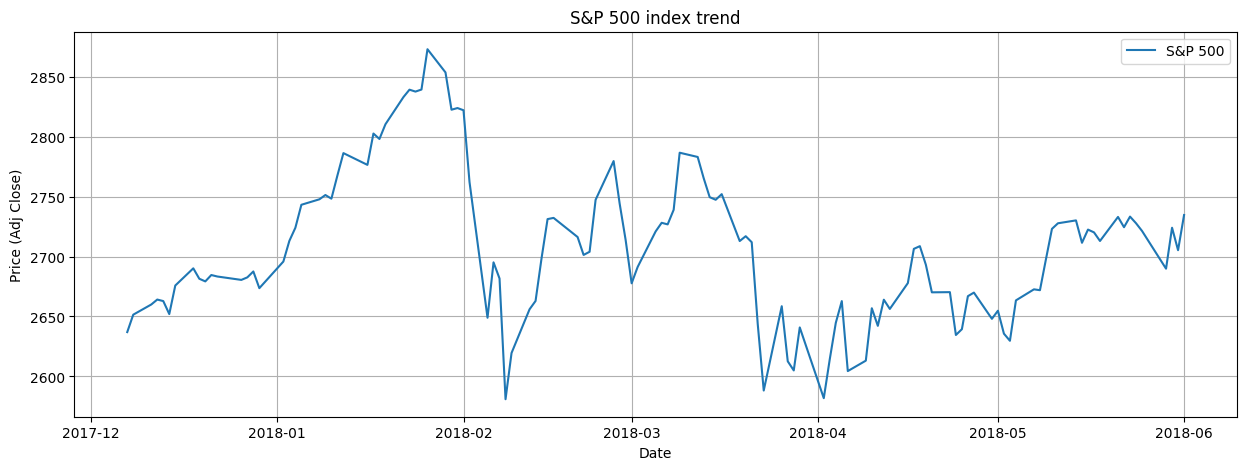

In [ ]:
START_DATE = "2017-12-07"
END_DATE = "2018-06-02"

def backward_trading_days(start_date:str, n_days:int) -> str:
  nyse = mcal.get_calendar("NYSE")
  start_date = pd.Timestamp(start_date)
  trading_days = nyse.valid_days(start_date=start_date-pd.Timedelta(days=365), end_date=start_date)
  idx = trading_days.get_indexer([start_date])[0]
  return trading_days[idx - n_days].strftime("%Y-%m-%d")

START_DATE_MA50 = backward_trading_days(START_DATE, 49)  # 49 trading days before START_DATE to obtain valid MA50

spx = yf.download("^GSPC", start=START_DATE_MA50, end=END_DATE, auto_adjust=False)[["Adj Close"]]
spx.columns = ["Adj_Close"]
window_size = 10

# Plotting only on chosen period
plt.figure(figsize=(15, 5))
plt.plot(spx.loc[START_DATE:].index, spx.loc[START_DATE:]["Adj_Close"], label="S&P 500")
plt.title("S&P 500 index trend")
plt.xlabel("Date")
plt.ylabel("Price (Adj Close)")
plt.legend()
plt.grid(True)
plt.show()

### Main intuition behind this project: enriching the paper data features (made of prices and sentiment scores from news titles) with technical and exogenous indicators.
### Adding features

In [ ]:
# Technical indicators

def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean() # adjust = False is needed for the recursive formula, more used in trading wrt classic EMA
    avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def zscore(series: pd.Series, window: int = 20) -> pd.Series:
    return (series - series.rolling(window=window).mean()) / series.rolling(window=window).std(ddof=0) # ddof=0 for population std often used in technical analysis

def rolling_vol(logret: pd.Series, window: int = 20, trading_days: int = 252):
    return logret.rolling(window).std() * np.sqrt(trading_days)

spx["log_ret"] = np.log(spx["Adj_Close"]).diff()

spx["ma10"] = spx["Adj_Close"].rolling(10).mean()
spx["ma50"] = spx["Adj_Close"].rolling(50).mean()

spx["rsi14"] = rsi(spx["Adj_Close"], period=14)

spx["zscore_20"] = zscore(spx["Adj_Close"], window=20)

spx["rolling_vol_20"] = rolling_vol(spx["log_ret"], window=20)

In [ ]:
# Exogenous indicators

vix = yf.download("^VIX", start=START_DATE, end=END_DATE, auto_adjust=False)["Close"]
spx["vix"] = vix

START_DATE_WTI20 = backward_trading_days(START_DATE, 19)  # to obtain valid z score based on 20 days
wti = yf.download("CL=F", start=START_DATE_WTI20, end=END_DATE, auto_adjust=False)["Close"]   # 19 trading days before START_DATE to obtain valid zscore_20
wti_log_ret = np.log(wti).diff()   # being a price series, we use log returns for stationarity as for spx
spx["wti_log_ret"] = wti_log_ret
wti_zscore_20 = zscore(wti, window=20)
spx["wti_zscore_20"] = wti_zscore_20

START_DATE_DT10Y2Y = backward_trading_days(START_DATE, 1)   # 1 trading day before START_DATE to obtain valid diff
t10y2y = pdr.DataReader("T10Y2Y", "fred", start=START_DATE_DT10Y2Y, end=END_DATE)
spx["t10y2y"] = t10y2y
dt10y2y = t10y2y.diff()
spx["dt10y2y"] = dt10y2y

spx = spx.loc[START_DATE:]
spx = spx.ffill()
assert len(spx) == 121, f"Unexpected length: {len(spx)}"


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Sentiment analysis with pretrained model FinBERT on FNSPID dataset

In [ ]:
# Replace any character that is NOT a letter, digit, space, or standard punctuation
def clean_text(text: object) -> str:
    text = fix_text(str(text))
    return re.sub(r'[^A-Za-z0-9\!\"\#\$\%\&\'\(\)\*\+,\-\.\/\:\;\<\=\>\?\@\[\\\]\^\_\`\{\|\}\~ ]', '', str(text))


def is_valid_title(title: object, min_length: int = 4) -> bool:
    title = str(title).strip()
    if len(title.split()) < min_length:
        return False
    if re.fullmatch(r'\d+', title):  # only numbers
        return False
    if re.fullmatch(r'[\W_]+', title):  # only symbols or punctuation
        return False
    if not re.search(r'[A-Za-zÀ-ÖØ-öø-ÿ]', title):  # no letters (included accents)
        return False
    return True


In [ ]:
NEWS_FILE = "./news.csv"
news = pd.read_csv(NEWS_FILE, parse_dates=["Date"])
news["Article_title"] = news["Article_title"].astype(str).apply(clean_text)

valid_titles = (news["Article_title"] != "") & (news["Article_title"].apply(is_valid_title))
news = news.loc[valid_titles, ["Date", "Article_title"]].reset_index(drop=True)

nyse = mcal.get_calendar("NYSE")
trading_days = set(nyse.valid_days(start_date=START_DATE, end_date=END_DATE).strftime("%Y-%m-%d"))
news = news[news["Date"].dt.strftime("%Y-%m-%d").isin(trading_days)].reset_index(drop=True)

assert "Date" in news.columns and "Article_title" in news.columns
print(news.head(10))
print(news.tail(10))
print(f"Available article titles: {len(news)}")


        Date                                      Article_title
0 2017-12-07  Ameren Shows Rising Relative Strength; Still S...
1 2017-12-07  Hologic's Panther Fusion Flu AdV/hMPV/RV Assay...
2 2017-12-07  Chemed Banks on Roto-Rooter Sales, Focuses on ...
3 2017-12-07  Walgreens Boots Invests in China to Fortify Re...
4 2017-12-07  Edwards Lifesciences Buys Harpoon Medical, Exp...
5 2017-12-07  Keysight (KEYS) Beats on Earnings in Q4, Reven...
6 2017-12-07  You'll Never Guess How Much $1,000 Invested in...
7 2017-12-07  CBOE Bitcoin Futures: How Will They Work and C...
8 2017-12-07  Bitcoin Screams To Record Highs In Wild Tradin...
9 2017-12-07  "Bitcoin Stocks" Get a New Member as Cboe Laun...
             Date                                      Article_title
283277 2018-06-01  Why Is WPX Energy (WPX) Up 5.6% Since Its Last...
283278 2018-06-01  Why Is Williams Partners (WPZ) Up 9.1% Since I...
283279 2018-06-01  W.R. Berkley Ups Dividend by 7.1%, OK's Specia...
283280 2018-06-01   

### FinBERT Model (finetuned on financial texts)
### Returns positive, negative and neutral probabilities. Sentiment score will be computed as probability of positive - probability of negative

In [ ]:
SENTIMENT_MODEL = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)

sentiment_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

### Computing sentiment scores for each trading day

In [ ]:
device = 0 if torch.cuda.is_available() else -1 # HuggingFace pipeline expects an integer

# encloses tokenizer, model, rules and device
nlp = TextClassificationPipeline(
    model=sentiment_model,
    tokenizer=tokenizer,
    task='text-classification',
    top_k=None,
    function_to_apply='softmax',
    device=device
)

'''
sentiment_scores = []
batch_size = 512
news_list = news["Article_title"].astype(str).fillna("").tolist()

# batch process news articles
for i in tqdm(range(0, len(news_list), batch_size),
              desc="Computing sentiment score for batched articles titles",
              total=len(news_list) // batch_size + 1):
    batch = news_list[i:i + batch_size]
    scores = nlp(batch, batch_size=batch_size)
    sentiment_scores.extend(scores)
df_sentiment = pd.DataFrame(sentiment_scores)
df_sentiment.to_csv("sentiment_short.csv", index=False)
'''

# Local use, after csv with scores has been computed once and then saved
sentiment_scores = pd.read_csv("./sentiment_short.csv")
sentiment_scores["Date"] = news["Date"]

sentiment_scores["dicts"] = sentiment_scores[["0", "1", "2"]].map(ast.literal_eval).values.tolist()
sentiment_scores["positive"] = sentiment_scores["dicts"].apply(
    lambda lst: next((d["score"] for d in lst if d["label"] == "positive"), 0.0)
)
sentiment_scores["negative"] = sentiment_scores["dicts"].apply(
    lambda lst: next((d["score"] for d in lst if d["label"] == "negative"), 0.0)
)

# Sentiment score computed for each day and then averaged by date (~ 0 means neutral)
sentiment_scores["score"] = sentiment_scores["positive"] - sentiment_scores["negative"]
sentiment_scores = sentiment_scores.drop(columns=["positive", "negative", "0", "1", "2", "dicts"])

sentiment_scores["Date"] = pd.to_datetime(sentiment_scores["Date"]).dt.date
sentiment_scores = sentiment_scores.groupby("Date").mean()
print(f"Computed daily sentiment for {len(sentiment_scores)} trading days")
print(sentiment_scores.tail(10))

spx["score"] = sentiment_scores["score"]

Device set to use cuda:0


Computed daily sentiment for 121 trading days
               score
Date                
2018-05-18  0.047613
2018-05-21  0.137879
2018-05-22  0.083531
2018-05-23  0.042550
2018-05-24  0.050981
2018-05-25  0.017180
2018-05-29 -0.006176
2018-05-30  0.111803
2018-05-31  0.063667
2018-06-01  0.131849


### Some visualizations for the dataset

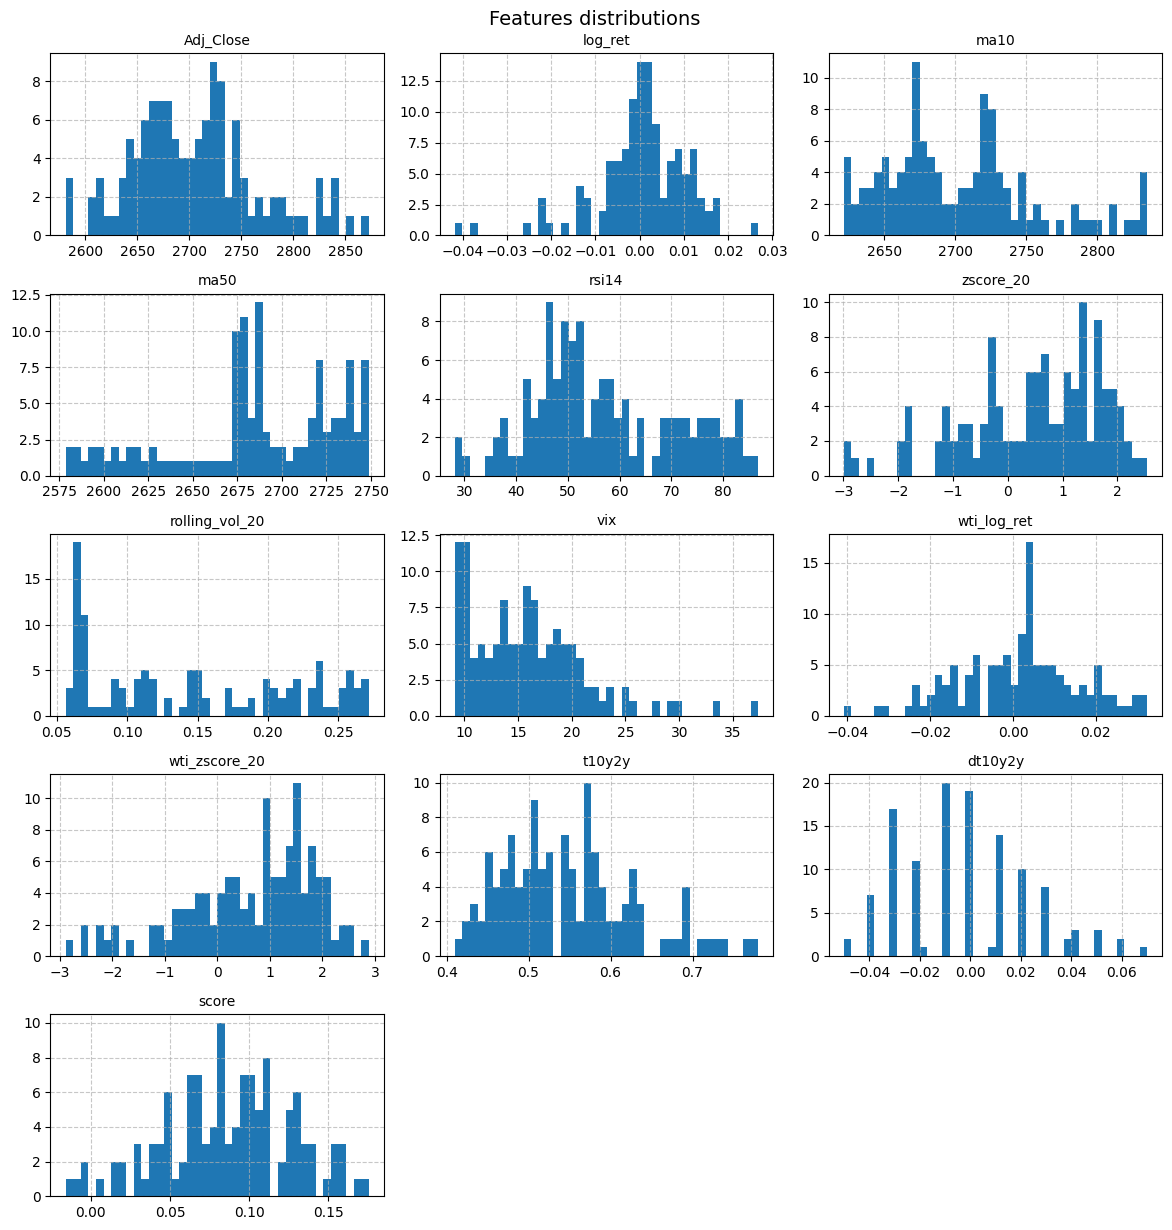

In [ ]:
features = spx.columns.tolist()
ncols = 3
nrows = np.ceil(len(features) / ncols).astype(int)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 2.5*nrows))
axes = axes.flatten()

for axis, feat in zip(axes, features):
    axis.hist(spx[feat], bins=40)
    axis.set_title(feat, fontsize=10)
    axis.grid(True, linestyle="--", alpha=0.7)
for axis in axes[len(features):]:
    axis.axis("off")

fig.suptitle("Features distributions", fontsize=14)
plt.tight_layout()
plt.show()

### Making distributions less asymmetric

In [ ]:
spx["ma10_pct"] = (spx["ma10"] - spx["Adj_Close"]) / spx["Adj_Close"]  # Percentage difference from adj closing price (stationary)
spx = spx.drop(columns=["ma10"], errors="ignore")

spx["ma50_pct"] = (spx["ma50"] - spx["Adj_Close"]) / spx["Adj_Close"]  # Percentage difference from adj closing price (stationary)
spx = spx.drop(columns=["ma50"], errors="ignore")

spx["rolling_vol_20_log"] = spx["rolling_vol_20"].apply(lambda x: np.log(x) if x > 0 else 0.00)
spx = spx.drop(columns=["rolling_vol_20"], errors="ignore")

spx["vix_log"] = spx["vix"].apply(lambda x: np.log(x) if x > 0 else 0.00)
spx = spx.drop(columns=["vix"], errors="ignore")

# Removing prices as training will be done on log returns (for stationarity)
spx = spx.drop(columns=["Adj_Close"], errors="ignore")

print(spx.head(10))

             log_ret      rsi14  zscore_20  wti_log_ret  wti_zscore_20  \
Date                                                                     
2017-12-07  0.002928  68.488209   1.221775     0.012961      -0.318301   
2017-12-08  0.005491  72.557235   1.579387     0.011749       0.339943   
2017-12-11  0.003197  74.620808   1.664731     0.010923       0.887691   
2017-12-12  0.001548  75.580466   1.597607    -0.014766       0.039161   
2017-12-13 -0.000473  74.650810   1.401064    -0.009495      -0.557483   
2017-12-14 -0.004079  67.013846   0.963472     0.007744      -0.215112   
2017-12-15  0.008934  73.438724   1.644702     0.004548      -0.051712   
2017-12-18  0.005348  76.420787   1.941572    -0.002446      -0.288751   
2017-12-19 -0.003235  71.207097   1.517546     0.005235       0.034002   
2017-12-20 -0.000828  69.895210   1.312190     0.010904       0.892061   

            t10y2y  dt10y2y     score  ma10_pct  ma50_pct  rolling_vol_20_log  \
Date                          

### Defining the dataset class

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(
            self,
            data: pd.DataFrame,
            start_date: str,
            end_date: str,
            target: str,
            window_size: int = 10,
            features: list[str] = None,  # if None, use all columns as features
            transform: callable = None,
            target_transform: callable = None
    ):
        data = data.loc[start_date:end_date].copy()   # end is inclusive

        if features is None:
            features = data.columns.tolist()

        y_shifted = data[target].shift(-1).dropna()  # next day target
        X_aligned = data.loc[y_shifted.index, features]

        self.X = X_aligned.astype(np.float32)
        self.y = y_shifted.astype(np.float32)

        self.window_size = window_size
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.X) - self.window_size + 1

    def __getitem__(self, idx):
        x = self.X.iloc[idx:idx + self.window_size]   # (window_size, n_features)
        y = self.y.iloc[idx + self.window_size - 1]

        if self.transform:
            x = self.transform(x)
        if self.target_transform:
            y = self.target_transform(y)
        return x, y

In [ ]:
class NormalizeX(object):
    def __init__(self, scaler: StandardScaler, cols_to_scale: list[str] = None):  # if None scale all columns
        self.cols_to_scale = cols_to_scale
        self.scaler = scaler

    def __call__(self, input: pd.DataFrame) -> pd.DataFrame:
        x = input.copy()
        if self.cols_to_scale is not None:
            x.loc[:, self.cols_to_scale] = self.scaler.transform(x[self.cols_to_scale])
        if self.cols_to_scale is None:
            x = pd.DataFrame(self.scaler.transform(x), index=input.index, columns=input.columns)
        if "rsi14" in x.columns:
            x["rsi14"] = (x["rsi14"] - 50) / 50  # Normalize RSI not using StandardScaler to preserve its financial meaning
        return x.astype(np.float32)

class NormalizeY(object):
    def __init__(self, scaler: StandardScaler):
        self.scaler = scaler

    def __call__(self, label):
        y = label.copy()
        y = (y - self.scaler.mean_[0]) / self.scaler.scale_[0]
        return np.float32(y)


class ToTensor(object):
    def __call__(self, value) -> torch.Tensor:
        if isinstance(value, pd.DataFrame) or isinstance(value, pd.Series):
            return torch.from_numpy(value.values).to(torch.float32)
        else:
            return torch.as_tensor(value).to(torch.float32)


# First approach: paper dataset


In [ ]:
TRAIN_START_DATE = "2017-12-07"
TRAIN_END_DATE = "2018-04-09"

target = "log_ret"

cols_to_scale = [col for col in spx.columns if col not in ["rsi14", "zscore_20", "wti_zscore_20"]]

training_days = spx.loc[TRAIN_START_DATE:TRAIN_END_DATE].copy()  # normalization only possible wrt training set to avoid data leakage
x_scaler = StandardScaler().fit(training_days[cols_to_scale])
y_scaler = StandardScaler().fit(training_days[[target]])

transform = transforms.Compose([
    NormalizeX(scaler=x_scaler, cols_to_scale=cols_to_scale),
    ToTensor()
])

target_transform = transforms.Compose([
    NormalizeY(scaler=y_scaler),
    ToTensor()
])

training_set = TimeSeriesDataset(
    data=spx,
    start_date=TRAIN_START_DATE,
    end_date=TRAIN_END_DATE,
    target=target,
    transform=transform,
    target_transform=target_transform
)

print(f"Training set size: {len(training_set)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {training_set[0][0].shape} and y is a tensor of shape {training_set[0][1].shape}")


Training set size: 73 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 12]) and y is a tensor of shape torch.Size([])


In [ ]:
VAL_START_DATE = "2018-04-10"
VAL_END_DATE = "2018-05-04"

validation_set = TimeSeriesDataset(
    data=spx,
    start_date=VAL_START_DATE,
    end_date=VAL_END_DATE,
    target=target,
    transform=transform,
    target_transform=target_transform
)

print(f"Validation set size: {len(validation_set)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {validation_set[0][0].shape} and y is a tensor of shape {validation_set[0][1].shape}")

TEST_START_DATE = "2018-05-07"
TEST_END_DATE = "2018-06-01"

test_set = TimeSeriesDataset(
    data=spx,
    start_date=TEST_START_DATE,
    end_date=TEST_END_DATE,
    target=target,
    transform=transform,
    target_transform=target_transform
)

print(f"Test set size: {len(test_set)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {test_set[0][0].shape} and y is a tensor of shape {test_set[0][1].shape}")

Validation set size: 9 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 12]) and y is a tensor of shape torch.Size([])
Test set size: 9 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 12]) and y is a tensor of shape torch.Size([])


### Models definition and tuning objective

In [ ]:
train_dataloader = DataLoader(training_set, batch_size=len(training_set))  # Full set in one batch -> Lightning expects a DataLoader
val_dataloader = DataLoader(validation_set, batch_size=len(validation_set))
test_dataloader = DataLoader(test_set, batch_size=len(test_set))

In [ ]:
class LitLSTM(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_layers, dropout, lr, weight_decay):
        super().__init__()
        self.save_hyperparameters()   # all params can be found in self.hparams

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True   # dataloader is (batch_dim, window_len, # features)
        )

        self.fc = nn.Linear(hidden_size, 1)  # output is a single value (next day log return)

        self.criterion = nn.MSELoss()
        self.apply(self._init_weights)
        self.train_losses_batch = []
        self.train_losses_epoch = []
        self.val_losses = []

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

    def training_step(self, batch, batch_idx):
        x, y = batch
        if y.ndim == 1:
            y = y.unsqueeze(-1)
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.train_losses_batch.append(loss.item())
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        epoch_loss = sum(self.train_losses_batch) / len(self.train_losses_batch)
        self.train_losses_epoch.append(epoch_loss)
        self.train_losses_batch = []

    def validation_step(self, batch, batch_idx):
        x, y = batch
        if y.ndim == 1:
            y = y.unsqueeze(-1)
        val_loss = self.criterion(self(x), y)
        self.val_losses.append(val_loss.item())
        self.log('val_loss', val_loss, on_step=False, on_epoch=True, prog_bar=False)
        return val_loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, _ = batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

    def _init_weights(self, module):
        if isinstance(module, nn.LSTM):
            for name, param in module.named_parameters():
                if 'weight_ih' in name:
                    nn.init.xavier_uniform_(param)
                elif 'weight_hh' in name:
                    for hh in param.chunk(4, 0):
                        nn.init.orthogonal_(hh)
                elif 'bias' in name:
                    nn.init.zeros_(param)
                    hidden_size = module.hidden_size
                    param.data[hidden_size:2*hidden_size] = 1.0   # forget gate bias to 1 -> initially 'forgetting less'
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

In [ ]:
# len_data is the sample size of the dataset, not the size in trading days, also min_train and val_len are in sample size and not trading days size
def make_ts_folds_on_days(len_data, n_folds, min_train, val_len, window_size=10):
    ts_folds = []
    fold_step = (len_data - (min_train + window_size + val_len - 1)) // (n_folds - 1)
    for i in range(n_folds):

        train_end_sample = min_train + i * fold_step
        train_end_day = train_end_sample + window_size - 1  # last day used in train. Here end is inclusive

        val_start_sample = train_end_day + 1

        val_end_sample = val_start_sample + val_len - 1
        val_end_day = val_end_sample + window_size

        ts_folds.append((train_end_day, val_end_day))
    return ts_folds

def objective_lstm(trial):
    hidden_size  = trial.suggest_int("hidden_size", 8, 64)
    num_layers   = trial.suggest_int("num_layers", 2, 6)
    dropout      = trial.suggest_float("dropout", 0.1, 0.5)
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [4, 8, 16])

    patience     = 10
    max_epochs   = 800

    ts_folds = make_ts_folds_on_days(len(training_set), n_folds=4, min_train=36, val_len=9)

    folds_best_vals, folds_best_epochs = [], []
    start_loc = spx.index.get_loc(TRAIN_START_DATE)
    pl.seed_everything(1)

    for fold_idx, (train_end_day, val_end_day) in enumerate(ts_folds):

        # Every fold data have to be standardized only wrt the inner training set
        train_days = spx.iloc[start_loc:start_loc + train_end_day + 1]   # Here end is exclusive
        scal_x = StandardScaler().fit(train_days[cols_to_scale])
        scal_y = StandardScaler().fit(train_days[[target]])

        transform = transforms.Compose([
            NormalizeX(scaler=scal_x, cols_to_scale=cols_to_scale),
            ToTensor()
        ])

        target_transform = transforms.Compose([
            NormalizeY(scaler=scal_y),
            ToTensor()
        ])

        train_end_str = spx.index[start_loc + train_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        train_set = TimeSeriesDataset(
            data=spx,
            start_date=TRAIN_START_DATE,
            end_date=train_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        val_start_str = spx.index[start_loc + train_end_day].strftime("%Y-%m-%d")
        val_end_str = spx.index[start_loc + val_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        val_set = TimeSeriesDataset(
            data=spx,
            start_date=val_start_str,
            end_date=val_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=False)

        val_loader = DataLoader(
            val_set,
            batch_size=len(val_set),
            shuffle=False,
            drop_last=False)

        lstm = LitLSTM(
            input_size=12,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay
        )

        ckpt_cb = pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1, filename=f"fold{fold_idx}"+"-{epoch:03d}-{val_loss:.6f}")
        es_cb   = pl.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=False)

        trainer = pl.Trainer(
            max_epochs=max_epochs,
            callbacks=[ckpt_cb, es_cb],
            log_every_n_steps=1,
            gradient_clip_val=1.0,
            enable_progress_bar=False
        )
        trainer.fit(lstm, train_loader, val_loader)

        best_val_this_fold  = ckpt_cb.best_model_score.detach().cpu().item()
        best_epoch_this_fold = int(torch.load(ckpt_cb.best_model_path)["epoch"])

        folds_best_vals.append(best_val_this_fold)
        folds_best_epochs.append(best_epoch_this_fold)

        trial.report(best_val_this_fold, step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    median_best_epochs = int(np.median(folds_best_epochs))
    trial.set_user_attr("Folds_Best_Vals", folds_best_vals)
    trial.set_user_attr("Median_Best_Epochs", median_best_epochs)
    trial.set_user_attr("Folds_Best_Epochs", folds_best_epochs)
    return float(np.mean(folds_best_vals))

In [ ]:
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=10,
    n_warmup_steps=0,
    interval_steps=1
)

In [ ]:
study = optuna.create_study(study_name="lstm_study", direction="minimize", pruner=pruner)
study.optimize(objective_lstm, n_trials=100)

best_trial_lstm = study.best_trial
print("Best hyperparams:", best_trial_lstm.params, "| CV loss:", best_trial_lstm.value)
print("Folds best epochs:", best_trial_lstm.user_attrs.get("Folds_Best_Epochs"))
print("Median epoch (CV):", best_trial_lstm.user_attrs.get("Median_Best_Epochs"))

folds_best_vals = best_trial_lstm.user_attrs.get("Folds_Best_Vals")

if folds_best_vals is not None:
    folds_best_vals = np.array(folds_best_vals)
    mean_val = np.mean(folds_best_vals)
    std_val = np.std(folds_best_vals)
    cv = std_val / mean_val if mean_val != 0 else float('nan')
    print(f"Per-fold best val_losses: {folds_best_vals}")
    print(f"Mean val_loss across folds: {mean_val:.6f}")
    print(f"Std val_loss across folds: {std_val:.6f}")
    print(f"Coeff. of variation: {cv:.2%}")

summary = {
    "best_params": best_trial_lstm.params,
    "objective_mean": float(best_trial_lstm.value),
    "folds_best_vals": folds_best_vals.tolist(),
    "folds_best_epochs": best_trial_lstm.user_attrs.get("Folds_Best_Epochs"),
    "median_best_epochs": best_trial_lstm.user_attrs.get("Median_Best_Epochs"),
    "mean_fold_val": float(mean_val) if folds_best_vals is not None else None,
    "std_fold_val": float(std_val) if folds_best_vals is not None else None,
    "cv_fold_val": float(cv) if folds_best_vals is not None else None
}

with open("optuna_lstm_summary.json", "w") as f:
    json.dump(summary, f, indent=2)


Output streaming troncato alle ultime 5000 righe.
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | lstm      | LSTM    | 6.4 K  | train
1 | fc        | Linear  | 12     | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
6.4 K     Trainable params
0         Non-trainable params
6.4 K     Total params
0.026     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name      | Type    | Params | Mode 
--------------------

Best hyperparams: {'hidden_size': 37, 'num_layers': 6, 'dropout': 0.3025537303898722, 'lr': 0.0014298459631432647, 'weight_decay': 1.0339389465497453e-06, 'batch_size': 4} | CV loss: 1.3312376588582993
Folds best epochs: [0, 3, 5, 27]
Median epoch (CV): 4
Per-fold best val_losses: [0.70906955 0.5773834  1.86791825 2.17057943]
Mean val_loss across folds: 1.331238
Std val_loss across folds: 0.697838
Coeff. of variation: 52.42%


In [ ]:
class LitGRU(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_layers, dropout, lr, weight_decay):
        super().__init__()
        self.save_hyperparameters()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

        self.criterion = nn.MSELoss()
        self.apply(self._init_weights)
        self.train_losses_batch = []
        self.train_losses_epoch = []
        self.val_losses = []

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

    def training_step(self, batch, batch_idx):
        x, y = batch
        if y.ndim == 1:
            y = y.unsqueeze(-1)
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.train_losses_batch.append(loss.item())
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        epoch_loss = sum(self.train_losses_batch) / len(self.train_losses_batch)
        self.train_losses_epoch.append(epoch_loss)
        self.train_losses_batch = []

    def validation_step(self, batch, batch_idx):
        x, y = batch
        if y.ndim == 1:
            y = y.unsqueeze(-1)
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.val_losses.append(loss.item())
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, _ = batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

    def _init_weights(self, module):
        if isinstance(module, nn.GRU):
            for name, param in module.named_parameters():
                if 'weight_ih' in name:
                    nn.init.xavier_uniform_(param)
                elif 'weight_hh' in name:
                    for hh in param.chunk(3, 0):
                        nn.init.orthogonal_(hh)
                elif "bias_ih" in name:
                    nn.init.zeros_(param)
                elif "bias_hh" in name:
                    nn.init.zeros_(param)
                    hs = module.hidden_size
                    param.data[hs:2*hs] = 1.0   # update gate bias to 1 -> initially 'forgetting less'
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

In [ ]:
def objective_gru(trial):
    hidden_size  = trial.suggest_int("hidden_size", 8, 64)
    num_layers   = trial.suggest_int("num_layers", 2, 6)
    dropout      = trial.suggest_float("dropout", 0.1, 0.5)
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [4, 8, 16])

    patience     = 10
    max_epochs   = 800

    ts_folds = make_ts_folds_on_days(len(training_set), n_folds=4, min_train=36, val_len=9)

    folds_best_vals, folds_best_epochs = [], []
    start_loc = spx.index.get_loc(TRAIN_START_DATE)
    pl.seed_everything(1)

    for fold_idx, (train_end_day, val_end_day) in enumerate(ts_folds):

        # Every fold data have to be standardized only wrt the inner training set
        train_days = spx.iloc[start_loc:start_loc + train_end_day + 1]   # Here end is exclusive
        scal_x = StandardScaler().fit(train_days[cols_to_scale])
        scal_y = StandardScaler().fit(train_days[[target]])

        transform = transforms.Compose([
            NormalizeX(scaler=scal_x, cols_to_scale=cols_to_scale),
            ToTensor()
        ])

        target_transform = transforms.Compose([
            NormalizeY(scaler=scal_y),
            ToTensor()
        ])

        train_end_str = spx.index[start_loc + train_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        train_set = TimeSeriesDataset(
            data=spx,
            start_date=TRAIN_START_DATE,
            end_date=train_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        val_start_str = spx.index[start_loc + train_end_day].strftime("%Y-%m-%d")
        val_end_str = spx.index[start_loc + val_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        val_set = TimeSeriesDataset(
            data=spx,
            start_date=val_start_str,
            end_date=val_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=False)

        val_loader = DataLoader(
            val_set,
            batch_size=len(val_set),
            shuffle=False,
            drop_last=False)

        gru = LitGRU(
            input_size=12,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay
        )

        ckpt_cb = pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1, filename=f"fold{fold_idx}"+"-{epoch:03d}-{val_loss:.6f}")
        es_cb   = pl.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=False)

        trainer = pl.Trainer(
            max_epochs=max_epochs,
            callbacks=[ckpt_cb, es_cb],
            log_every_n_steps=1,
            gradient_clip_val=1.0,
            enable_progress_bar=False
        )
        trainer.fit(gru, train_loader, val_loader)

        best_val_this_fold  = ckpt_cb.best_model_score.detach().cpu().item()
        best_epoch_this_fold = int(torch.load(ckpt_cb.best_model_path)["epoch"])

        folds_best_vals.append(best_val_this_fold)
        folds_best_epochs.append(best_epoch_this_fold)

        trial.report(best_val_this_fold, step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    median_best_epochs = int(np.median(folds_best_epochs))
    trial.set_user_attr("Folds_Best_Vals", folds_best_vals)
    trial.set_user_attr("Median_Best_Epochs", median_best_epochs)
    trial.set_user_attr("Folds_Best_Epochs", folds_best_epochs)
    return float(np.mean(folds_best_vals))

In [ ]:
study = optuna.create_study(study_name="gru_study", direction="minimize", pruner=pruner)
study.optimize(objective_gru, n_trials=100)

best_trial_gru = study.best_trial
print("Best hyperparams:", best_trial_gru.params, "| CV loss:", best_trial_gru.value)
print("Folds best epochs:", best_trial_gru.user_attrs.get("Folds_Best_Epochs"))
print("Median epoch (CV):", best_trial_gru.user_attrs.get("Median_Best_Epochs"))

folds_best_vals = best_trial_gru.user_attrs.get("Folds_Best_Vals")

if folds_best_vals is not None:
    folds_best_vals = np.array(folds_best_vals)
    mean_val = np.mean(folds_best_vals)
    std_val = np.std(folds_best_vals)
    cv = std_val / mean_val if mean_val != 0 else float('nan')
    print(f"Per-fold best val_losses: {folds_best_vals}")
    print(f"Mean val_loss across folds: {mean_val:.6f}")
    print(f"Std val_loss across folds: {std_val:.6f}")
    print(f"Coeff. of variation: {cv:.2%}")

summary = {
    "best_params": best_trial_gru.params,
    "objective_mean": float(best_trial_gru.value),
    "folds_best_vals": folds_best_vals.tolist(),
    "folds_best_epochs": best_trial_gru.user_attrs.get("Folds_Best_Epochs"),
    "median_best_epochs": best_trial_gru.user_attrs.get("Median_Best_Epochs"),
    "mean_fold_val": float(mean_val) if folds_best_vals is not None else None,
    "std_fold_val": float(std_val) if folds_best_vals is not None else None,
    "cv_fold_val": float(cv) if folds_best_vals is not None else None
}

with open("optuna_gru_short_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

[I 2025-09-22 10:35:40,059] A new study created in memory with name: gru_study
INFO: Seed set to 1
INFO:lightning.fabric.utilities.seed:Seed set to 1
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | gru       | GRU     | 39.4 K | train
1 | fc        | Linear  | 38     | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
39.4 K    Trainable params
0         Non-trainable params
39.4 K    Total p

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Output streaming troncato alle ultime 5000 righe.
5.4 K     Trainable params
0         Non-trainable params
5.4 K     Total params
0.022     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | gru       | GRU     | 5.4 K  | train
1 | fc        | Linear  | 23     | train
2 | criterion | MSELoss | 0      | train
-----------------------------

Best hyperparams: {'hidden_size': 14, 'num_layers': 5, 'dropout': 0.3217970367655676, 'lr': 0.001830326224366545, 'weight_decay': 0.00017690457208478815, 'batch_size': 8} | CV loss: 1.402898296713829
Folds best epochs: [22, 0, 14, 0]
Median epoch (CV): 7
Per-fold best val_losses: [0.59278828 0.61740232 1.84849608 2.55290651]
Mean val_loss across folds: 1.402898
Std val_loss across folds: 0.835817
Coeff. of variation: 59.58%


First trial approach has been shown not to provide a reliable estimate of the validation loss.
Given the small number of samples a stable and general process cannot be achieved, hence the second approach is the one to consider.

# Second trial: enlarged dataset

[*********************100%***********************]  1 of 1 completed


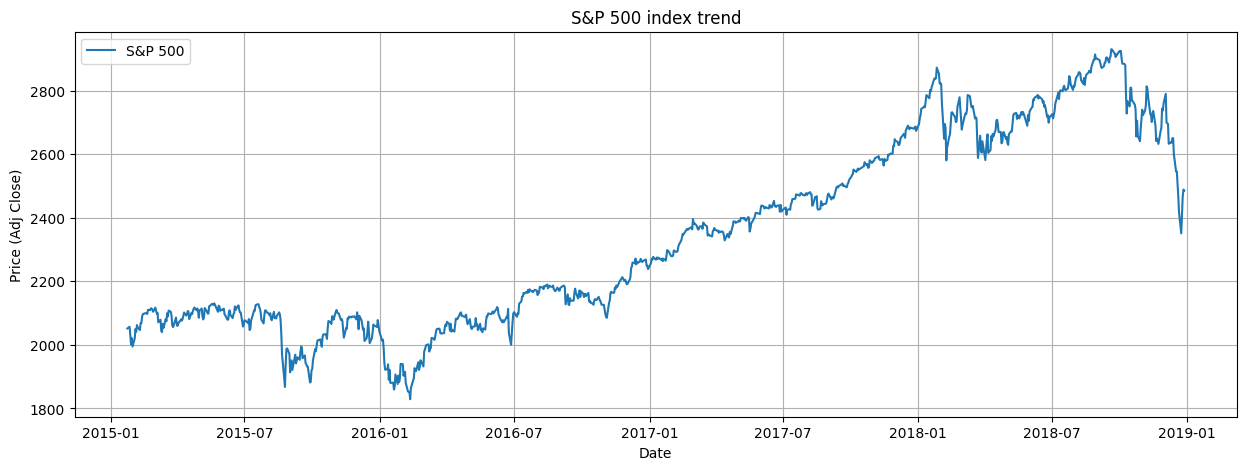

In [ ]:
START_DATE = "2015-01-23"
END_DATE = "2018-12-31"

START_DATE_MA50 = backward_trading_days(START_DATE, 49)  # 49 trading days before START_DATE to obtain valid MA50

spx = yf.download("^GSPC", start=START_DATE_MA50, end=END_DATE, auto_adjust=False)[["Adj Close"]]
spx.columns = ["Adj_Close"]

# Plotting only on chosen period
plt.figure(figsize=(15, 5))
plt.plot(spx.loc[START_DATE:].index, spx.loc[START_DATE:]["Adj_Close"], label="S&P 500")
plt.title("S&P 500 index trend")
plt.xlabel("Date")
plt.ylabel("Price (Adj Close)")
plt.legend()
plt.grid(True)
plt.show()

### Adding features

In [ ]:
# Technical indicators

spx["log_ret"] = np.log(spx["Adj_Close"]).diff()

spx["ma10"] = spx["Adj_Close"].rolling(10).mean()
spx["ma50"] = spx["Adj_Close"].rolling(50).mean()

spx["rsi14"] = rsi(spx["Adj_Close"], period=14)

spx["zscore_20"] = zscore(spx["Adj_Close"], window=20)

spx["rolling_vol_20"] = rolling_vol(spx["log_ret"], window=20)

In [ ]:
# Exogenous indicators

vix = yf.download("^VIX", start=START_DATE, end=END_DATE, auto_adjust=False)["Close"]
spx["vix"] = vix

START_DATE_WTI20 = backward_trading_days(START_DATE, 19)
wti = yf.download("CL=F", start=START_DATE_WTI20, end=END_DATE, auto_adjust=False)["Close"]
wti_log_ret = np.log(wti).diff()
spx["wti_log_ret"] = wti_log_ret
wti_zscore_20 = zscore(wti, window=20)
spx["wti_zscore_20"] = wti_zscore_20

START_DATE_DT10Y2Y = backward_trading_days(START_DATE, 1)
t10y2y = pdr.DataReader("T10Y2Y", "fred", start=START_DATE_DT10Y2Y, end=END_DATE)
spx["t10y2y"] = t10y2y
dt10y2y = t10y2y.diff()
spx["dt10y2y"] = dt10y2y

spx = spx.loc[START_DATE:]
spx = spx.ffill()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Computing sentiment scores

In [ ]:
NEWS_FILE = "./news_long.csv"
news = pd.read_csv(NEWS_FILE, parse_dates=["Date"])
news["Article_title"] = news["Article_title"].astype(str).apply(clean_text)

valid_titles = (news["Article_title"] != "") & (news["Article_title"].apply(is_valid_title))
news = news.loc[valid_titles, ["Date", "Article_title"]].reset_index(drop=True)

nyse = mcal.get_calendar("NYSE")
trading_days = set(nyse.valid_days(start_date=START_DATE, end_date=END_DATE).strftime("%Y-%m-%d"))
news = news[news["Date"].dt.strftime("%Y-%m-%d").isin(trading_days)].reset_index(drop=True)

assert "Date" in news.columns and "Article_title" in news.columns
print(news.head(10))
print(news.tail(10))
print(f"Available article titles: {len(news)}")

        Date                                      Article_title
0 2015-01-23  Can Advance Auto Parts Drive Gains From Acquis...
1 2015-01-23  Southwest Airlines Co. (LUV) Rises: Stock Move...
2 2015-01-23  Altera (ALTR) Tops Earnings; Shares Dip on Rev...
3 2015-01-23  KLA-Tencor Tops Q2 Estimates, Shares Down on W...
4 2015-01-23  Ardelyx (ARDX) Catches Eye: Stock Gains 5.2% -...
5 2015-01-23  Will Freeport (FCX) Keep the Earnings Streak A...
6 2015-01-23  What's in Store for Citizens Financial (CFG) i...
7 2015-01-23  Will Las Vegas Sands (LVS) Disappoint Again Th...
8 2015-01-23  Friday Sector Laggards: Precious Metals, Non-P...
9 2015-01-23  Kansas City Southern Beats on Q4 Earnings, Lag...
                       Date                                      Article_title
2877230 2018-12-28 07:47:21  Och-Ziff Capital Management shares are trading...
2877231 2018-12-28 09:18:02  Mid-Day Market Update: Crude Oil Up Over 1%; Q...
2877232 2018-12-28 09:43:17       26 Stocks Moving In Frida

In [ ]:
news_list = news["Article_title"].astype(str).fillna("").tolist()

sentiment_dataset = Dataset.from_dict({"text": news_list})

def compute_sentiment(batch):
    results = nlp(batch["text"], batch_size=len(batch["text"]))
    return {"sentiment_scores": results}

dataset = sentiment_dataset.map(compute_sentiment, batched=True, batch_size=2048, remove_columns=["text"], desc="Computing sentiment scores")

sentiment_df = pd.DataFrame(dataset["sentiment_scores"])
sentiment_df.to_csv("sentiment_long.csv", index=False)

Computing sentiment scores:   0%|          | 0/2877240 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
sentiment_scores_long = pd.read_csv("./sentiment_long.csv")

sentiment_scores_long["Date"] = news["Date"]
assert len(sentiment_scores_long) == len(news)

sentiment_scores_long["dicts"] = sentiment_scores_long[["0", "1", "2"]].map(ast.literal_eval).values.tolist()
sentiment_scores_long["positive"] = sentiment_scores_long["dicts"].apply(
    lambda lst: next((d["score"] for d in lst if d["label"] == "positive"), 0.0)
)
sentiment_scores_long["negative"] = sentiment_scores_long["dicts"].apply(
    lambda lst: next((d["score"] for d in lst if d["label"] == "negative"), 0.0)
)

# Sentiment score computed for each day and then averaged by date (~ 0 means neutral)
sentiment_scores_long["score"] = sentiment_scores_long["positive"] - sentiment_scores_long["negative"]
sentiment_scores_long = sentiment_scores_long.drop(columns=["positive", "negative", "0", "1", "2", "dicts"])

sentiment_scores_long["Date"] = pd.to_datetime(sentiment_scores_long["Date"]).dt.date
sentiment_scores_long = sentiment_scores_long.groupby("Date").mean()
print(f"Computed daily sentiment for {len(sentiment_scores_long)} trading days")
print(sentiment_scores_long.tail(10))

sentiment_scores_long.to_csv('sentiment_scores_long.csv')

Computed daily sentiment for 991 trading days
               score
Date                
2018-12-14 -0.129012
2018-12-17 -0.107914
2018-12-18  0.127243
2018-12-19  0.002142
2018-12-20 -0.029737
2018-12-21  0.020697
2018-12-24 -0.026960
2018-12-26  0.157802
2018-12-27  0.052446
2018-12-28  0.123995


In [ ]:
spx["score"] = sentiment_scores_long["score"]
print(spx.head(10))
print(spx.tail(10))

              Adj_Close   log_ret         ma10         ma50      rsi14  \
Date                                                                     
2015-01-23  2051.820068 -0.005507  2028.910022  2046.887800  52.842317   
2015-01-26  2057.090088  0.002565  2030.138025  2047.236001  54.049016   
2015-01-27  2029.550049 -0.013478  2030.267029  2047.062002  47.245354   
2015-01-28  2002.160034 -0.013588  2028.180029  2046.318604  41.632316   
2015-01-29  2021.250000  0.009490  2029.178027  2045.947205  46.411038   
2015-01-30  1994.989990 -0.013077  2029.410022  2045.020605  41.390870   
2015-02-02  2020.849976  0.012879  2029.553015  2044.401604  47.422254   
2015-02-03  2050.030029  0.014336  2032.301013  2044.427805  53.266429   
2015-02-04  2041.510010 -0.004165  2033.240015  2044.203005  51.467582   
2015-02-05  2062.520020  0.010239  2033.177026  2044.183406  55.461901   

            zscore_20  rolling_vol_20        vix  wti_log_ret  wti_zscore_20  \
Date                           

In [ ]:
print("New dataset has length:", len(spx))

New dataset has length: 991


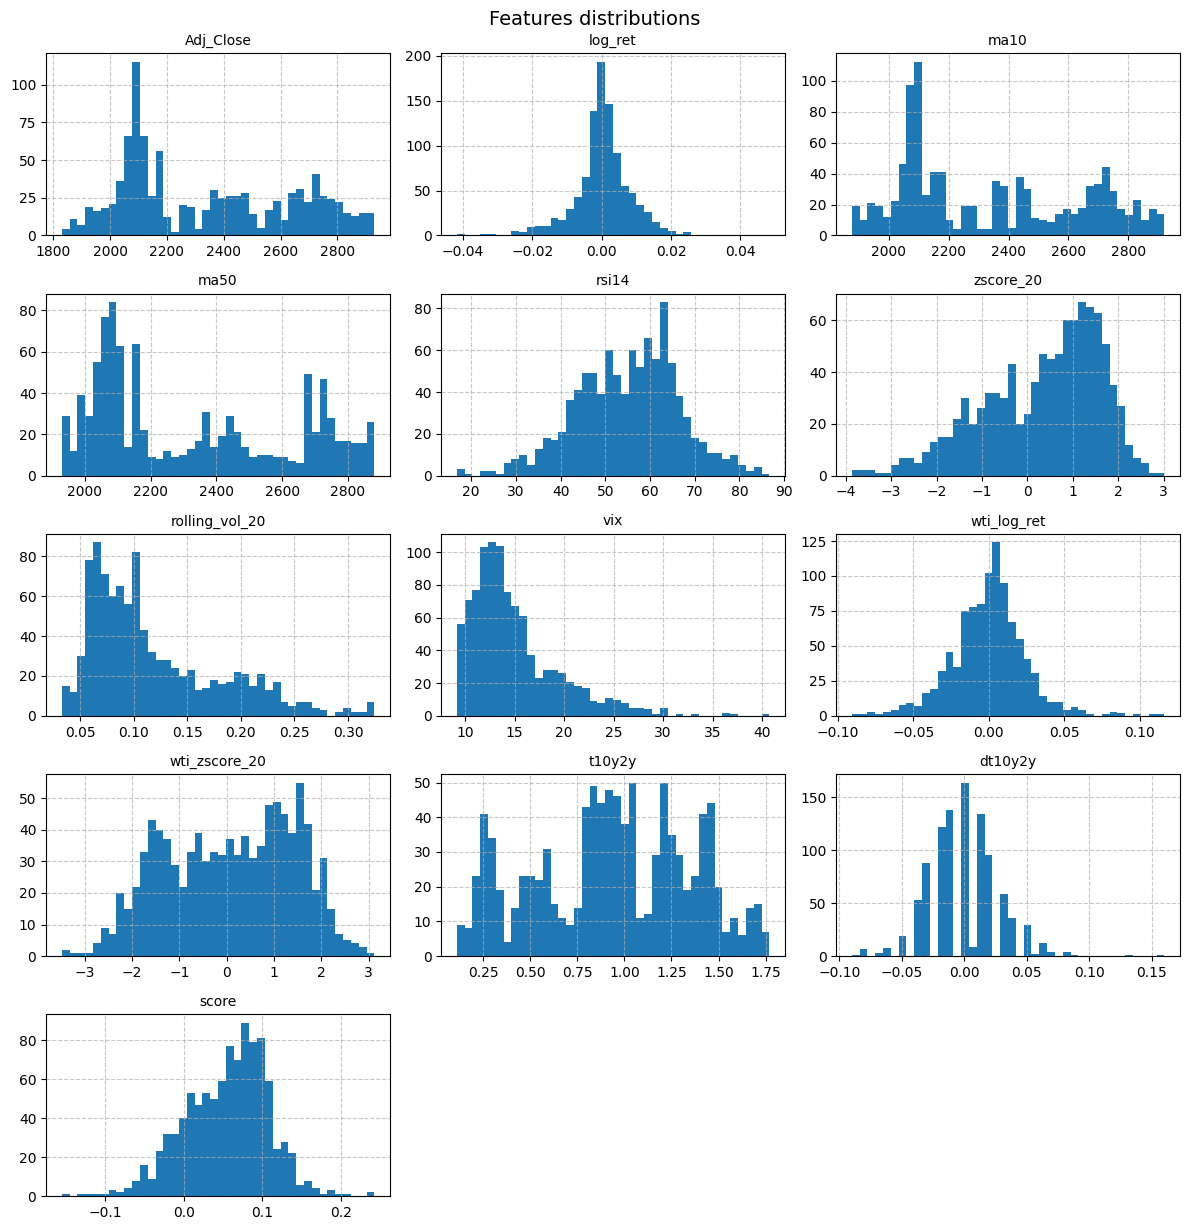

In [ ]:
features = spx.columns.tolist()
ncols = 3
nrows = np.ceil(len(features) / ncols).astype(int)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 2.5*nrows))
axes = axes.flatten()

for axis, feat in zip(axes, features):
    axis.hist(spx[feat], bins=40)
    axis.set_title(feat, fontsize=10)
    axis.grid(True, linestyle="--", alpha=0.7)
for axis in axes[len(features):]:
    axis.axis("off")

fig.suptitle("Features distributions", fontsize=14)
plt.tight_layout()
plt.show()

### Making distributions less asymmetric

In [ ]:
spx["ma10_pct"] = (spx["ma10"] - spx["Adj_Close"]) / spx["Adj_Close"]  # Percentage difference from adj closing price (stationary)
spx = spx.drop(columns=["ma10"], errors="ignore")

spx["ma50_pct"] = (spx["ma50"] - spx["Adj_Close"]) / spx["Adj_Close"]  # Percentage difference from adj closing price (stationary)
spx = spx.drop(columns=["ma50"], errors="ignore")

spx["rolling_vol_20_log"] = spx["rolling_vol_20"].apply(lambda x: np.log(x) if x > 0 else 0.00)
spx = spx.drop(columns=["rolling_vol_20"], errors="ignore")

spx["vix_log"] = spx["vix"].apply(lambda x: np.log(x) if x > 0 else 0.00)
spx = spx.drop(columns=["vix"], errors="ignore")

# Removing prices as training will be done on log returns (for stationarity)
spx = spx.drop(columns=["Adj_Close"], errors="ignore")

print(spx.head(10))
print(spx.tail(10))

             log_ret      rsi14  zscore_20  wti_log_ret  wti_zscore_20  \
Date                                                                     
2015-01-23 -0.005507  52.842317   0.310927    -0.015670      -1.196937   
2015-01-26  0.002565  54.049016   0.562891    -0.009698      -1.252595   
2015-01-27 -0.013478  47.245354  -0.365238     0.023639      -0.825289   
2015-01-28 -0.013588  41.632316  -1.374762    -0.039264      -1.365027   
2015-01-29  0.009490  46.411038  -0.481840     0.001798      -1.295233   
2015-01-30 -0.013077  41.390870  -1.548158     0.080025       0.464727   
2015-02-02  0.012879  47.422254  -0.268494     0.027197       1.471563   
2015-02-03  0.014336  53.266429   1.062961     0.067849       2.881114   
2015-02-04 -0.004165  51.467582   0.580455    -0.090702       0.552004   
2015-02-05  0.010239  55.461901   1.440964     0.041045       1.450843   

            t10y2y  dt10y2y     score  ma10_pct  ma50_pct  rolling_vol_20_log  \
Date                          

### Creating training, validation and test sets

In [ ]:
TRAIN_START_DATE = "2015-01-23"
TRAIN_END_DATE = "2018-04-09"   # 80% of data

target = "log_ret"

cols_to_scale = [col for col in spx.columns if col not in ["rsi14", "zscore_20", "wti_zscore_20"]]

training_days = spx.loc[TRAIN_START_DATE:TRAIN_END_DATE].copy()  # normalization only possible wrt training set to avoid data leakage
x_scaler = StandardScaler().fit(training_days[cols_to_scale])
y_scaler = StandardScaler().fit(training_days[[target]])

transform = transforms.Compose([
    NormalizeX(scaler=x_scaler, cols_to_scale=cols_to_scale),
    ToTensor()
])

target_transform = transforms.Compose([
    NormalizeY(scaler=y_scaler),
    ToTensor()
])

training_set = TimeSeriesDataset(
    data=spx,
    start_date=TRAIN_START_DATE,
    end_date=TRAIN_END_DATE,
    target=target,
    transform=transform,
    target_transform=target_transform
)

print(f"Training set size: {len(training_set)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {training_set[0][0].shape} and y is a tensor of shape {training_set[0][1].shape}")

Training set size: 798 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 12]) and y is a tensor of shape torch.Size([])


In [ ]:
VAL_START_DATE = "2018-04-10"
VAL_END_DATE = "2018-08-16"

validation_set = TimeSeriesDataset(
    data=spx,
    start_date=VAL_START_DATE,
    end_date=VAL_END_DATE,
    target=target,
    transform=transform,
    target_transform=target_transform
)

print(f"Validation set size: {len(validation_set)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {validation_set[0][0].shape} and y is a tensor of shape {validation_set[0][1].shape}")

TEST_START_DATE = "2018-08-17"
TEST_END_DATE = "2018-12-28"

test_set = TimeSeriesDataset(
    data=spx,
    start_date=TEST_START_DATE,
    end_date=TEST_END_DATE,
    target=target,
    transform=transform,
    target_transform=target_transform
)

print(f"Test set size: {len(test_set)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {test_set[0][0].shape} and y is a tensor of shape {test_set[0][1].shape}")

Validation set size: 81 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 12]) and y is a tensor of shape torch.Size([])
Test set size: 82 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 12]) and y is a tensor of shape torch.Size([])


### Defining tuning objective

In [ ]:
def objective_lstm_long(trial): # reducing trials because of time limits
    hidden_size  = trial.suggest_int("hidden_size", 16, 48, step=8)
    num_layers   = trial.suggest_int("num_layers", 2, 4)
    dropout      = trial.suggest_float("dropout", 0.1, 0.4, step=0.05)
    lr           = trial.suggest_float("lr", 5e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [16, 32])

    patience     = 40
    max_epochs   = 300

    ts_folds = make_ts_folds_on_days(len(training_set), n_folds=4, min_train=600, val_len=50)

    folds_best_vals, folds_best_epochs = [], []
    start_loc = spx.index.get_loc(TRAIN_START_DATE)
    pl.seed_everything(1)

    for fold_idx, (train_end_day, val_end_day) in enumerate(ts_folds):

        # Every fold data have to be standardized only wrt the inner training set
        train_days = spx.iloc[start_loc:start_loc + train_end_day + 1]   # Here end is exclusive
        scal_x = StandardScaler().fit(train_days[cols_to_scale])
        scal_y = StandardScaler().fit(train_days[[target]])

        transform = transforms.Compose([
            NormalizeX(scaler=scal_x, cols_to_scale=cols_to_scale),
            ToTensor()
        ])

        target_transform = transforms.Compose([
            NormalizeY(scaler=scal_y),
            ToTensor()
        ])

        train_end_str = spx.index[start_loc + train_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        train_set = TimeSeriesDataset(
            data=spx,
            start_date=TRAIN_START_DATE,
            end_date=train_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        val_start_str = spx.index[start_loc + train_end_day].strftime("%Y-%m-%d")
        val_end_str = spx.index[start_loc + val_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        val_set = TimeSeriesDataset(
            data=spx,
            start_date=val_start_str,
            end_date=val_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=False)

        val_loader = DataLoader(
            val_set,
            batch_size=len(val_set),
            shuffle=False,
            drop_last=False)

        lstm = LitLSTM(
            input_size=12,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay
        )

        ckpt_cb = pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1, filename=f"fold{fold_idx}"+"-{epoch:03d}-{val_loss:.6f}")
        es_cb   = pl.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=False)

        trainer = pl.Trainer(
            max_epochs=max_epochs,
            callbacks=[ckpt_cb, es_cb],
            log_every_n_steps=1,
            gradient_clip_val=1.0,
            enable_progress_bar=False
        )
        trainer.fit(lstm, train_loader, val_loader)

        best_val_this_fold  = ckpt_cb.best_model_score.detach().cpu().item()
        best_epoch_this_fold = int(torch.load(ckpt_cb.best_model_path)["epoch"])

        folds_best_vals.append(best_val_this_fold)
        folds_best_epochs.append(best_epoch_this_fold)

        trial.report(best_val_this_fold, step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    median_best_epochs = int(np.median(folds_best_epochs))
    trial.set_user_attr("Folds_Best_Vals", folds_best_vals)
    trial.set_user_attr("Median_Best_Epochs", median_best_epochs)
    trial.set_user_attr("Folds_Best_Epochs", folds_best_epochs)
    return float(np.mean(folds_best_vals))

In [ ]:
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=0,
    interval_steps=1
)

In [ ]:
study = optuna.create_study(study_name="lstm_long_study", direction="minimize", pruner=pruner)
study.optimize(objective_lstm_long, n_trials=20)

best_trial_lstm = study.best_trial
print("Best hyperparams:", best_trial_lstm.params, "| CV loss:", best_trial_lstm.value)
print("Folds best epochs:", best_trial_lstm.user_attrs.get("Folds_Best_Epochs"))
print("Median epoch (CV):", best_trial_lstm.user_attrs.get("Median_Best_Epochs"))

folds_best_vals = best_trial_lstm.user_attrs.get("Folds_Best_Vals")

if folds_best_vals is not None:
    folds_best_vals = np.array(folds_best_vals)
    mean_val = np.mean(folds_best_vals)
    std_val = np.std(folds_best_vals)
    cv = std_val / mean_val if mean_val != 0 else float('nan')
    print(f"Per-fold best val_losses: {folds_best_vals}")
    print(f"Mean val_loss across folds: {mean_val:.6f}")
    print(f"Std val_loss across folds: {std_val:.6f}")
    print(f"Coeff. of variation: {cv:.2%}")

summary = {
    "best_params": best_trial_lstm.params,
    "objective_mean": float(best_trial_lstm.value),
    "folds_best_vals": folds_best_vals.tolist(),
    "folds_best_epochs": best_trial_lstm.user_attrs.get("Folds_Best_Epochs"),
    "median_best_epochs": best_trial_lstm.user_attrs.get("Median_Best_Epochs"),
    "mean_fold_val": float(mean_val) if folds_best_vals is not None else None,
    "std_fold_val": float(std_val) if folds_best_vals is not None else None,
    "cv_fold_val": float(cv) if folds_best_vals is not None else None
}

with open("optuna_lstm_long_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

[I 2025-09-21 20:38:54,346] A new study created in memory with name: lstm_long_study
INFO: Seed set to 1
INFO:lightning.fabric.utilities.seed:Seed set to 1
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | lstm      | LSTM    | 21.8 K | train
1 | fc        | Linear  | 41     | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
21.8 K    Trainable params
0         Non-trainable params
21.8 K    T

Best hyperparams: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.30000000000000004, 'lr': 0.0020251226433172344, 'weight_decay': 8.991219620712505e-06, 'batch_size': 32} | CV loss: 1.0281035676598549
Folds best epochs: [1, 2, 9, 34]
Median epoch (CV): 5
Per-fold best val_losses: [0.30860305 0.13529184 0.37050331 3.29801607]
Mean val_loss across folds: 1.028104
Std val_loss across folds: 1.313367
Coeff. of variation: 127.75%


In [ ]:
def objective_gru_long(trial): # reducing trials because of time limits
    hidden_size  = trial.suggest_int("hidden_size", 16, 48, step=8)
    num_layers   = trial.suggest_int("num_layers", 2, 4)
    dropout      = trial.suggest_float("dropout", 0.1, 0.4, step=0.05)
    lr           = trial.suggest_float("lr", 5e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [16, 32])

    patience     = 40
    max_epochs   = 300

    ts_folds = make_ts_folds_on_days(len(training_set), n_folds=4, min_train=600, val_len=50)

    folds_best_vals, folds_best_epochs = [], []
    start_loc = spx.index.get_loc(TRAIN_START_DATE)
    pl.seed_everything(1)

    for fold_idx, (train_end_day, val_end_day) in enumerate(ts_folds):

        # Every fold data have to be standardized only wrt the inner training set
        train_days = spx.iloc[start_loc:start_loc + train_end_day + 1]   # Here end is exclusive
        scal_x = StandardScaler().fit(train_days[cols_to_scale])
        scal_y = StandardScaler().fit(train_days[[target]])

        transform = transforms.Compose([
            NormalizeX(scaler=scal_x, cols_to_scale=cols_to_scale),
            ToTensor()
        ])

        target_transform = transforms.Compose([
            NormalizeY(scaler=scal_y),
            ToTensor()
        ])

        train_end_str = spx.index[start_loc + train_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        train_set = TimeSeriesDataset(
            data=spx,
            start_date=TRAIN_START_DATE,
            end_date=train_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        val_start_str = spx.index[start_loc + train_end_day].strftime("%Y-%m-%d")
        val_end_str = spx.index[start_loc + val_end_day - 1].strftime("%Y-%m-%d")   # dataset DatetimeIndex end is inclusive
        val_set = TimeSeriesDataset(
            data=spx,
            start_date=val_start_str,
            end_date=val_end_str,
            target=target,
            transform=transform,
            target_transform=target_transform,
        )

        train_loader = DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            drop_last=False)

        val_loader = DataLoader(
            val_set,
            batch_size=len(val_set),
            shuffle=False,
            drop_last=False)

        gru = LitGRU(
            input_size=12,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay
        )

        ckpt_cb = pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1, filename=f"gru_fold{fold_idx}"+"-{epoch:03d}-{val_loss:.6f}")
        es_cb   = pl.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=False)

        trainer = pl.Trainer(
            max_epochs=max_epochs,
            callbacks=[ckpt_cb, es_cb],
            log_every_n_steps=1,
            gradient_clip_val=1.0,
            enable_progress_bar=False
        )
        trainer.fit(gru, train_loader, val_loader)

        best_val_this_fold  = ckpt_cb.best_model_score.detach().cpu().item()
        best_epoch_this_fold = int(torch.load(ckpt_cb.best_model_path)["epoch"])

        folds_best_vals.append(best_val_this_fold)
        folds_best_epochs.append(best_epoch_this_fold)

        trial.report(best_val_this_fold, step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    median_best_epochs = int(np.median(folds_best_epochs))
    trial.set_user_attr("Folds_Best_Vals", folds_best_vals)
    trial.set_user_attr("Median_Best_Epochs", median_best_epochs)
    trial.set_user_attr("Folds_Best_Epochs", folds_best_epochs)
    return float(np.mean(folds_best_vals))

In [ ]:
study = optuna.create_study(study_name="gru_long_study", direction="minimize", pruner=pruner)
study.optimize(objective_gru_long, n_trials=20)

best_trial_gru = study.best_trial
print("Best hyperparams:", best_trial_gru.params, "| CV loss:", best_trial_gru.value)
print("Folds best epochs:", best_trial_gru.user_attrs.get("Folds_Best_Epochs"))
print("Median epoch (CV):", best_trial_gru.user_attrs.get("Median_Best_Epochs"))

folds_best_vals = best_trial_gru.user_attrs.get("Folds_Best_Vals")

if folds_best_vals is not None:
    folds_best_vals = np.array(folds_best_vals)
    mean_val = np.mean(folds_best_vals)
    std_val = np.std(folds_best_vals)
    cv = std_val / mean_val if mean_val != 0 else float('nan')
    print(f"Per-fold best val_losses: {folds_best_vals}")
    print(f"Mean val_loss across folds: {mean_val:.6f}")
    print(f"Std val_loss across folds: {std_val:.6f}")
    print(f"Coeff. of variation: {cv:.2%}")   # = std/mean → misura relativa di instabilità (più è basso, più i fold sono consistenti).

summary = {
    "best_params": best_trial_gru.params,
    "objective_mean": float(best_trial_gru.value),
    "folds_best_vals": folds_best_vals.tolist(),
    "folds_best_epochs": best_trial_gru.user_attrs.get("Folds_Best_Epochs"),
    "median_best_epochs": best_trial_gru.user_attrs.get("Median_Best_Epochs"),
    "mean_fold_val": float(mean_val) if folds_best_vals is not None else None,
    "std_fold_val": float(std_val) if folds_best_vals is not None else None,
    "cv_fold_val": float(cv) if folds_best_vals is not None else None
}

with open("optuna_gru_long_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

[I 2025-09-22 08:36:49,562] A new study created in memory with name: gru_long_study
INFO: Seed set to 1
INFO:lightning.fabric.utilities.seed:Seed set to 1
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | gru       | GRU     | 13.5 K | train
1 | fc        | Linear  | 25     | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
13.6 K    Trainable params
0         Non-trainable params
13.6 K    To

Best hyperparams: {'hidden_size': 24, 'num_layers': 4, 'dropout': 0.30000000000000004, 'lr': 0.004714708272771977, 'weight_decay': 2.702880345007101e-05, 'batch_size': 32} | CV loss: 1.063505832105875
Folds best epochs: [9, 1, 76, 6]
Median epoch (CV): 7
Per-fold best val_losses: [0.30792928 0.12883918 0.33528981 3.48196507]
Mean val_loss across folds: 1.063506
Std val_loss across folds: 1.398548
Coeff. of variation: 131.50%


Altough coefficients of variation results higher than in the first approach, the validation losses are more stable across folds, while at the same time covering a much bigger time period. For what it concerns the out-of-scale val loss in the fourth fold, it is likely due to a market regime shift, as data in that specific period may have suddenly been strongly different than training ones. To avoid this, an even larger and more comprehensive training set may be a solution, but it was not pursued in this work being computationally expensive given the available resources.

### Training the sub-models with the best configurations found. Since best epoch estimates are not reliable, as validation sets may differ substantially from training sets, the approach of the reference paper is followed, fixing the training to 100 epochs. This length allows the networks to converge and extract meaningful patterns, whereas shorter training (e.g., 10 epochs) proved insufficient to yield satisfactory results.

In [ ]:
training_dataloader = DataLoader(
            training_set,
            batch_size=32,   # from optuna tuning
            shuffle=True,
            drop_last=False)

In [ ]:
# best hyperparameters from optuna tuning
lstm = LitLSTM(
    input_size=12,
    hidden_size=32,
    num_layers=3,
    dropout=0.3,
    lr=0.0020251226433172344,
    weight_decay=8.991219620712505e-06
)

trainer = pl.Trainer(
    max_epochs=100,
    gradient_clip_val=1.0,
    log_every_n_steps=1
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(lstm, training_dataloader)

trainer.save_checkpoint("lstm_final_100ep.ckpt")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | lstm      | LSTM    | 22.8 K | train
1 | fc        | Linear  | 33     | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
22.8 K    Trainable params
0         Non-trainable params
22.8 K    Total params
0.091     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | lstm      | LSTM    | 22.8 K | train
1 | fc        | Linear  | 33     | train
2 | criterion |

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
# best hyperparameters from optuna tuning
gru = LitGRU(
    input_size=12,
    hidden_size=24,
    num_layers=4,
    dropout=0.3,
    lr=0.004714708272771977,
    weight_decay=2.702880345007101e-05
)

trainer.fit(gru, training_dataloader)

trainer.save_checkpoint("gru_final_100ep.ckpt")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | gru       | GRU     | 13.5 K | train
1 | fc        | Linear  | 25     | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
13.6 K    Trainable params
0         Non-trainable params
13.6 K    Total params
0.054     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | gru       | GRU     | 13.5 K | train
1 | fc        | Linear  | 25     | train
2 | criterion |

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


### Once that level 1 models are trained, tuning and training of meta learner takes place.

In [ ]:
trained_lstm_path = "./lstm_final_100ep.ckpt"
trained_lstm = LitLSTM.load_from_checkpoint(trained_lstm_path)

trained_gru_path = "./gru_final_100ep.ckpt"
trained_gru = LitGRU.load_from_checkpoint(trained_gru_path)

validation_dataloader = DataLoader(
            validation_set,
            batch_size=len(validation_set),
            shuffle=False,
            drop_last=False)

trainer = pl.Trainer(logger=False, enable_checkpointing=False)
predictions_lstm = trainer.predict(trained_lstm, dataloaders=validation_dataloader)
predictions_gru = trainer.predict(trained_gru, dataloaders=validation_dataloader)

y_pred_lstm = torch.cat(predictions_lstm, dim=0).cpu().numpy()
y_pred_gru = torch.cat(predictions_gru, dim=0).cpu().numpy()
print(y_pred_lstm.shape)
print(y_pred_gru.shape)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

(81, 1)
(81, 1)


In [ ]:
y_meta_list = []
for _, y in validation_dataloader:
    y_meta_list.append(y)

y_meta = torch.cat(y_meta_list, dim=0).unsqueeze(-1)

X_meta = torch.cat((torch.from_numpy(y_pred_lstm), torch.from_numpy(y_pred_gru)), dim=1)
print("Shape of meta features: ", X_meta.shape)
print("Shape of meta targets: ", y_meta.shape)

torch.Size([81, 1])
torch.Size([81, 2])


In [ ]:
class LitMETA(pl.LightningModule):
    def __init__(self, input_size, hidden_size, num_layers, dropout, lr, weight_decay):
        super().__init__()
        self.save_hyperparameters()   # all params can be found in self.hparams

        layers = []

        current_input_size = input_size
        for i in range(num_layers):
            layers.append(nn.Linear(current_input_size, hidden_size))
            layers.append(nn.LeakyReLU())
            layers.append(nn.Dropout(dropout))
            current_input_size = hidden_size

        layers.append(nn.Linear(current_input_size, 1))

        self.net = nn.Sequential(*layers)

        self.criterion = nn.MSELoss()
        self.apply(self._init_weights)
        self.train_losses_batch = []
        self.train_losses_epoch = []
        self.val_losses = []

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        if y.ndim == 1:
            y = y.unsqueeze(-1)
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.train_losses_batch.append(loss.item())
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        epoch_loss = sum(self.train_losses_batch) / len(self.train_losses_batch)
        self.train_losses_epoch.append(epoch_loss)
        self.train_losses_batch = []

    def validation_step(self, batch, batch_idx):
        x, y = batch
        if y.ndim == 1:
            y = y.unsqueeze(-1)
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.val_losses.append(loss.item())
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, _ = batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)


### Again divide in train/val to make optuna study

In [ ]:
X_train, X_val = X_meta[:int(0.8*len(X_meta))], X_meta[int(0.8*len(X_meta)):]
y_train, y_val = y_meta[:int(0.8*len(y_meta))], y_meta[int(0.8*len(y_meta)):]

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

torch.Size([64, 2])
torch.Size([17, 2])
torch.Size([64, 1])
torch.Size([17, 1])


In [ ]:
train_dataset = TensorDataset(X_train.float(), y_train.float())
val_dataset   = TensorDataset(X_val.float(), y_val.float())

In [ ]:
def objective_meta(trial):
    hidden_size  = trial.suggest_int("hidden_size", 16, 128)
    num_layers   = trial.suggest_int("num_layers", 1, 4)
    dropout      = trial.suggest_float("dropout", 0.0, 0.5)
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [4, 8, 16])

    patience = 40
    max_epochs = 500

    meta = LitMETA(
        input_size=2,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    ckpt_cb = pl.callbacks.ModelCheckpoint(
        dirpath="meta_checkpoints",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        filename=f"meta_best_trial{trial.number}"
        )
    es_cb = pl.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=patience, verbose=False)

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        callbacks=[ckpt_cb, es_cb],
        log_every_n_steps=1,
        enable_progress_bar=False
    )

    trainer.fit(meta, train_loader, val_loader)
    print(f"Trial {trial.number} finished. Epochs run: {trainer.current_epoch}")

    return trainer.callback_metrics["val_loss"].item()

In [ ]:
study = optuna.create_study(study_name="study_meta", direction="minimize")
study.optimize(objective_meta, n_trials=100)

print("Best hyperparams:", study.best_params)
print("Best value val_loss:", study.best_value)

best_trial = study.best_trial
best_ckpt_path = f"meta_checkpoints/meta_best_trial{best_trial.number}.ckpt"
print("Checkpoint with best value:", best_ckpt_path)

[I 2025-09-25 12:05:19,147] A new study created in memory with name: study_meta
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | net       | Sequential | 1.6 K  | train
1 | criterion | MSELoss    | 0      | train
-------------------------------------------------
1.6 K     Trainable params
0         Non-trainable params
1.6 K     Total params
0.006     Total estimated model params size (MB)
9         Modules in train mode
0        

Trial 0 finished. Epochs run: 140


[I 2025-09-25 12:05:26,825] Trial 1 finished with value: 0.4266427159309387 and parameters: {'hidden_size': 77, 'num_layers': 1, 'dropout': 0.20821769727703393, 'lr': 0.0001234574872140045, 'weight_decay': 0.007310681848283768, 'batch_size': 8}. Best is trial 0 with value: 0.42395398020744324.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | net       | Sequential | 153    | train
1 | criterion | MSELoss    | 0      | train
------

Trial 1 finished. Epochs run: 97


[I 2025-09-25 12:05:35,938] Trial 2 finished with value: 0.42909830808639526 and parameters: {'hidden_size': 38, 'num_layers': 1, 'dropout': 0.04577428577630133, 'lr': 0.00011122491635756005, 'weight_decay': 0.0005896087143679334, 'batch_size': 4}. Best is trial 0 with value: 0.42395398020744324.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | net       | Sequential | 13.9 K | train
1 | criterion | MSELoss    | 0      | train
---

...

Trial 97 finished. Epochs run: 81


[I 2025-09-25 12:09:33,417] Trial 98 finished with value: 0.42110589146614075 and parameters: {'hidden_size': 36, 'num_layers': 3, 'dropout': 0.47845519306782375, 'lr': 0.00015765772142776002, 'weight_decay': 9.116950873073772e-05, 'batch_size': 16}. Best is trial 11 with value: 0.41730716824531555.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | net       | Sequential | 1.4 K  | train
1 | criterion | MSELoss    | 0      | train


Trial 98 finished. Epochs run: 75


[I 2025-09-25 12:09:42,489] Trial 99 finished with value: 0.4200421869754791 and parameters: {'hidden_size': 25, 'num_layers': 3, 'dropout': 0.44857567489143474, 'lr': 0.0001149359867804522, 'weight_decay': 0.0001486726792550674, 'batch_size': 8}. Best is trial 11 with value: 0.41730716824531555.


Trial 99 finished. Epochs run: 208
Best hyperparams: {'hidden_size': 20, 'num_layers': 2, 'dropout': 0.33587770896377456, 'lr': 0.00019663787073478093, 'weight_decay': 0.002145532735265816, 'batch_size': 16}
Best value val_loss: 0.41730716824531555
Checkpoint with best value: meta_checkpoints/meta_best_trial11.ckpt


In [ ]:
best_meta = LitMETA.load_from_checkpoint("./meta_best_trial11.ckpt")
print(best_meta.hparams)

"dropout":      0.33587770896377456
"hidden_size":  20
"input_size":   2
"lr":           0.00019663787073478093
"num_layers":   2
"weight_decay": 0.002145532735265816


In [ ]:
meta = LitMETA(
    input_size=2,
    hidden_size=best_meta.hparams.hidden_size,
    num_layers=best_meta.hparams.num_layers,
    dropout=best_meta.hparams.dropout,
    lr=best_meta.hparams.lr,
    weight_decay=best_meta.hparams.weight_decay
)

meta_dataset = TensorDataset(X_meta.float(), y_meta.float())
meta_dataloader = DataLoader(
    meta_dataset,
    batch_size=16, # from optuna tuning
    shuffle=True,
    drop_last=False
)

trainer = pl.Trainer(
    max_epochs=180,  # from optuna tuning
    gradient_clip_val=1.0,
    log_every_n_steps=1
)

trainer.fit(meta, meta_dataloader)

trainer.save_checkpoint("meta_final.ckpt")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Ski

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=180` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=180` reached.


### All the models are trained. Now the predictions on test data

In [ ]:
test_dataloader = DataLoader(
            test_set,
            batch_size=len(test_set),
            shuffle=False,
            drop_last=False)

trainer = pl.Trainer(logger=False, enable_checkpointing=False)
test_lstm = trainer.predict(trained_lstm, dataloaders=test_dataloader)
test_gru = trainer.predict(trained_gru, dataloaders=test_dataloader)

test_pred_lstm = torch.cat(test_lstm, dim=0).cpu().numpy()
test_pred_gru = torch.cat(test_gru, dim=0).cpu().numpy()
print(test_pred_lstm.shape)
print(test_pred_gru.shape)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

(82, 1)
(82, 1)


In [ ]:
y_test_list = []
for _, y in test_dataloader:
    y_test_list.append(y)

X_meta_test = torch.cat((torch.from_numpy(test_pred_lstm), torch.from_numpy(test_pred_gru)), dim=1)
print(X_meta_test.shape)

y_test = torch.cat(y_test_list, dim=0).unsqueeze(-1)
print(y_test.shape)

test_meta_dataset = TensorDataset(X_meta_test.float(), y_test.float())
test_meta_dataloader = DataLoader(test_meta_dataset, batch_size=len(test_meta_dataset), shuffle=False)

trained_meta_path = "./meta_final.ckpt"
trained_meta = LitMETA.load_from_checkpoint(trained_meta_path)

y_final_pred_list = trainer.predict(trained_meta, dataloaders=test_meta_dataloader)
y_final_pred = torch.cat(y_final_pred_list, dim=0)

print(y_final_pred.shape)

torch.Size([82, 1])
torch.Size([82, 2])


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

torch.Size([82, 1])


In [ ]:
log_ret_pred_unscaled = y_final_pred * y_scaler.scale_[0] + y_scaler.mean_[0]
spx_test = spx.iloc[-log_ret_pred_unscaled.shape[0]:]
log_ret_test = spx_test["log_ret"]

y_pred = log_ret_pred_unscaled.view(-1)
y_true = torch.tensor(log_ret_test.values, dtype=y_pred.dtype, device=y_pred.device).view(-1)

criterion = nn.MSELoss()
test_mse_unscaled = criterion(y_pred, y_true).item()
print("Test MSE unscaled:", test_mse_unscaled)

test_rmse_unscaled = np.sqrt(test_mse_unscaled)
std_log_ret = np.std(log_ret_test.values, ddof=1)
nrmse = test_rmse_unscaled / std_log_ret
print("Test NRMSE unscaled:", nrmse)

Test MSE unscaled: 0.00017460515664424747
Test NRMSE unscaled: 1.0011641591196343


### Evaluate predictions with metrics used in the reference paper and more:
- MSE (here on log returns, not prices)
- NRMSE
- MPA (only on reconstruced prices, not really useful)
- Precision
- Recall
- F1-Score
- MDA

In [ ]:
# need to convert the predicted and actual log returns in positive/negative for directional metrics.
def to_direction(x, eps=0.0):
  return np.where(x > eps, 1, 0)

log_ret_test_np = log_ret_test.to_numpy(dtype=float).reshape(-1)
log_ret_pred_unsc_np = log_ret_pred_unscaled.detach().cpu().numpy().reshape(-1)

y_test_dir = to_direction(log_ret_test_np)
y_pred_dir = to_direction(log_ret_pred_unsc_np)

precision = precision_score(y_test_dir, y_pred_dir)
recall = recall_score(y_test_dir, y_pred_dir)
f1 = f1_score(y_test_dir, y_pred_dir)

mda = np.mean(np.sign(log_ret_test_np) == np.sign(log_ret_pred_unsc_np))

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("MDA:", mda)

Precision: 0.44680851063829785
Recall: 0.6176470588235294
F1-Score: 0.5185185185185185
MDA: 0.524390243902439


### To be in line with the paper, the MPA metric will be computed on reconstructed prices (also because MPA on log returns tends to explode). Prices will be reconstructed reanchoring daily, as it is done operatively live at the end of each day. Also because I am not trying to estimate a cumulative log return trajectory reconstruction, but the model only estimates log return at day t+1, hence when the next day comes, price of day t is known and accessible.


[*********************100%***********************]  1 of 1 completed


MPA (prices, re-anchored): 0.9907213278230808
MPA baseline: 0.9908507462440636


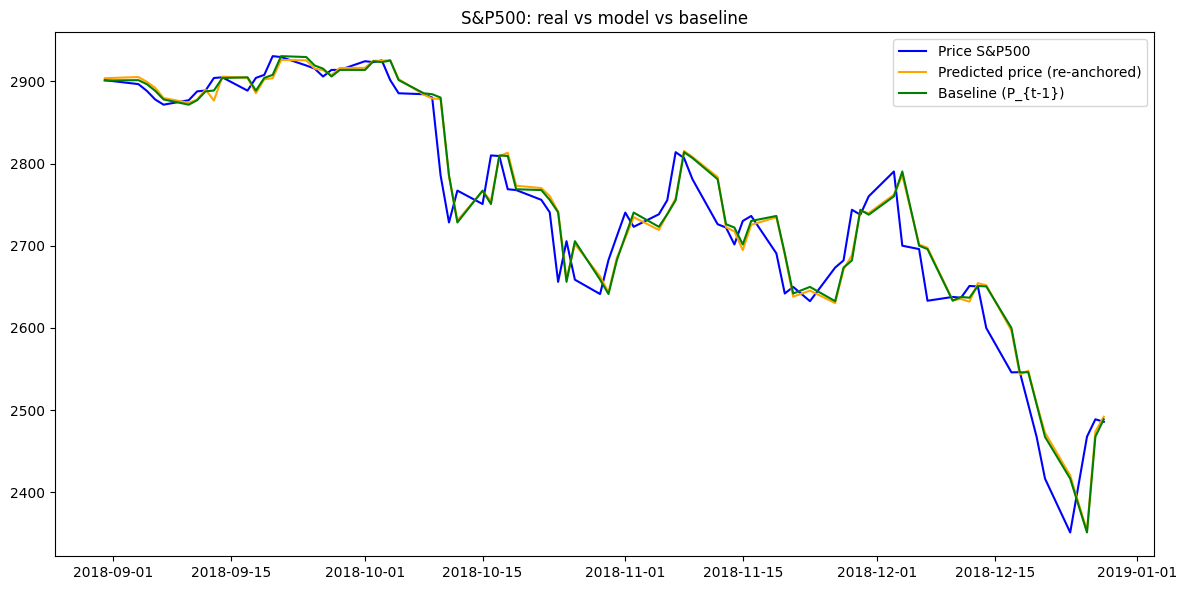

In [ ]:
spx_graph = yf.download("^GSPC", start=TEST_START_DATE, end=END_DATE, auto_adjust=False)["Adj Close"]

pred_idx = spx_graph.index[window_size:]  # t = window_size, window_size+1, ...

m = min(len(log_ret_pred_unsc_np), len(pred_idx))
y_pred = log_ret_pred_unsc_np[:m]
pred_idx = pred_idx[:m]

# Re-anchoring: P_hat_{t+1} = P_t * exp(r_hat_{t+1})
P_base = spx_graph.shift(1).loc[pred_idx].to_numpy().reshape(-1)
P_real = spx_graph.loc[pred_idx].to_numpy().reshape(-1)
P_pred = P_base * np.exp(y_pred).reshape(-1)

df_pred = pd.DataFrame({"P_real": P_real, "P_pred": P_pred}, index=pred_idx)

mpa_prices = 1 - np.mean(np.abs(df_pred["P_real"] - df_pred["P_pred"]) / df_pred["P_real"])
print("MPA (prices, re-anchored):", mpa_prices)

# baseline: prediction = previous day price
P_pred_naive = P_base

mpa_naive = 1 - np.mean(np.abs(df_pred["P_real"] - P_pred_naive) / df_pred["P_real"])
print("MPA baseline:", mpa_naive)

plt.figure(figsize=(12,6))
plt.plot(df_pred.index, df_pred["P_real"], label="Price S&P500", color="blue")
plt.plot(df_pred.index, df_pred["P_pred"], label="Predicted price (re-anchored)", color="orange")
plt.plot(df_pred.index, P_pred_naive, label="Baseline (P_{t-1})", color="green")
plt.legend()
plt.title("S&P500: real vs model vs baseline")
plt.tight_layout()
plt.show()

The naive baseline (predicting today’s price as yesterday’s) already achieves very high accuracy in financial data because prices are highly persistent. As a result, MPA values are often close to 100% and small differences between models are not very informative.

Instead, for comparison with the naive baseline on returns (i.e. always predicting log return = 0), other relevant metrics are computed.

In [ ]:
y_naive = np.zeros_like(log_ret_test_np)

naive_mse = mean_squared_error(log_ret_test_np, y_naive)
print("Naive MSE:", naive_mse)

naive_rmse = np.sqrt(naive_mse)
naive_nrmse = naive_rmse / std_log_ret
print("Naive NRMSE", naive_nrmse)

naive_pred_dir = to_direction(y_naive)

naive_precision = precision_score(y_test_dir, naive_pred_dir, zero_division=0)
naive_recall = recall_score(y_test_dir, naive_pred_dir)
naive_f1 = f1_score(y_test_dir, naive_pred_dir)

naive_mda = (y_test_dir == naive_pred_dir).mean()

print("Naive Precision:", naive_precision)
print("Naive Recall:", naive_recall)
print("Naive F1-Score:", naive_f1)
print("Naive MDA:", naive_mda)

Naive MSE: 0.0001756263276203576
Naive NRMSE 1.0040875244696197
Naive Precision: 0.0
Naive Recall: 0.0
Naive F1-Score: 0.0
Naive MDA: 0.5853658536585366


### Comparisons with other models

In [ ]:
# lstm, gru already trained on same data -> already have the test predictions

lstm_pred_unscaled = test_pred_lstm * y_scaler.scale_[0] + y_scaler.mean_[0]

lstm_pred_unscaled_torch = torch.tensor(lstm_pred_unscaled, dtype=torch.float32).view(-1)

lstm_mse_unscaled = criterion(lstm_pred_unscaled_torch, y_true).item()
print("LSTM MSE unscaled:", lstm_mse_unscaled)

lstm_rmse_unscaled = np.sqrt(lstm_mse_unscaled)
lstm_nrmse = lstm_rmse_unscaled / std_log_ret
print("LSTM NRMSE unscaled:", lstm_nrmse)

lstm_pred_dir = to_direction(lstm_pred_unscaled)

lstm_precision = precision_score(y_test_dir, lstm_pred_dir)
lstm_recall = recall_score(y_test_dir, lstm_pred_dir)
lstm_f1 = f1_score(y_test_dir, lstm_pred_dir)

lstm_mda = np.mean(np.sign(log_ret_test_np) == np.sign(lstm_pred_unscaled))

print("LSTM Precision:", lstm_precision)
print("LSTM Recall:", lstm_recall)
print("LSTM F1-Score:", lstm_f1)
print("LSTM MDA:", lstm_mda)

LSTM MSE unscaled: 0.00022027215163689107
LSTM NRMSE unscaled: 1.124492486623676
LSTM Precision: 0.34210526315789475
LSTM Recall: 0.38235294117647056
LSTM F1-Score: 0.3611111111111111
LSTM MDA: 0.5062462819750149


In [ ]:
gru_pred_unscaled = test_pred_gru * y_scaler.scale_[0] + y_scaler.mean_[0]

gru_pred_unscaled_torch = torch.tensor(gru_pred_unscaled, dtype=torch.float32).view(-1)

gru_mse_unscaled = criterion(gru_pred_unscaled_torch, y_true).item()
print("GRU MSE unscaled:", gru_mse_unscaled)

gru_rmse_unscaled = np.sqrt(gru_mse_unscaled)
gru_nrmse = gru_rmse_unscaled / std_log_ret
print("GRU NRMSE unscaled:", gru_nrmse)

gru_pred_dir = to_direction(gru_pred_unscaled)

gru_precision = precision_score(y_test_dir, gru_pred_dir)
gru_recall = recall_score(y_test_dir, gru_pred_dir)
gru_f1 = f1_score(y_test_dir, gru_pred_dir)

gru_mda = np.mean(np.sign(log_ret_test_np) == np.sign(gru_pred_unscaled))

print("GRU Precision:", gru_precision)
print("GRU Recall:", gru_recall)
print("GRU F1-Score:", gru_f1)
print("GRU MDA:", gru_mda)

GRU MSE unscaled: 0.0002608822542242706
GRU NRMSE unscaled: 1.2237678237887284
GRU Precision: 0.42424242424242425
GRU Recall: 0.4117647058823529
GRU F1-Score: 0.417910447761194
GRU MDA: 0.516656751933373


### Comparisons with other models with dataset made of 2 features (log return and sentiment score)

In [ ]:
spx_2f = spx[["log_ret", "score"]]

training_days_2f = spx_2f.loc[TRAIN_START_DATE:TRAIN_END_DATE].copy()  # normalization only possible wrt training set to avoid data leakage
x_scaler_2f = StandardScaler().fit(training_days_2f)

transform_2f = transforms.Compose([
    NormalizeX(scaler=x_scaler_2f),
    ToTensor()
])

target_transform_2f = transforms.Compose([
    NormalizeY(scaler=y_scaler),
    ToTensor()
])

training_set_2f = TimeSeriesDataset(
    data=spx_2f,
    start_date=TRAIN_START_DATE,
    end_date=TRAIN_END_DATE,
    target=target,
    transform=transform_2f,
    target_transform=target_transform_2f
)

print(f"Two features training set size: {len(training_set_2f)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {training_set_2f[0][0].shape} and y is a tensor of shape {training_set_2f[0][1].shape}")

validation_set_2f = TimeSeriesDataset(
    data=spx_2f,
    start_date=VAL_START_DATE,
    end_date=VAL_END_DATE,
    target=target,
    transform=transform_2f,
    target_transform=target_transform_2f
)

print(f"Two features validation set size: {len(validation_set_2f)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {validation_set_2f[0][0].shape} and y is a tensor of shape {validation_set_2f[0][1].shape}")

test_set_2f = TimeSeriesDataset(
    data=spx_2f,
    start_date=TEST_START_DATE,
    end_date=TEST_END_DATE,
    target=target,
    transform=transform_2f,
    target_transform=target_transform_2f
)

print(f"Two features test set size: {len(test_set_2f)} samples")
print(f"Each element of the dataset is a tuple (x, y) where x is a tensor of shape {test_set_2f[0][0].shape} and y is a tensor of shape {test_set_2f[0][1].shape}")

Two features training set size: 798 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 2]) and y is a tensor of shape torch.Size([])
Two features validation set size: 81 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 2]) and y is a tensor of shape torch.Size([])
Two features test set size: 82 samples
Each element of the dataset is a tuple (x, y) where x is a tensor of shape torch.Size([10, 2]) and y is a tensor of shape torch.Size([])


Models gets re-trained but hyperparameters are chosen to remain the same, as analyzed market trends and behaviour has remained the same.

In [ ]:
training_dataloader_2f = DataLoader(
            training_set_2f,
            batch_size=32,   # from optuna tuning
            shuffle=True,
            drop_last=False)

lstm_2f = LitLSTM(
    input_size=2,
    hidden_size=32,
    num_layers=3,
    dropout=0.3,
    lr=0.0020251226433172344,
    weight_decay=8.991219620712505e-06
)

trainer = pl.Trainer(
    max_epochs=100,
    gradient_clip_val=1.0,
    log_every_n_steps=1
)

trainer.fit(lstm_2f, training_dataloader_2f)
trainer.save_checkpoint("lstm2f_final_100ep.ckpt")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
gru_2f = LitGRU(
    input_size=2,
    hidden_size=24,
    num_layers=4,
    dropout=0.3,
    lr=0.004714708272771977,
    weight_decay=2.702880345007101e-05
)

trainer = pl.Trainer(
    max_epochs=100,
    gradient_clip_val=1.0,
    log_every_n_steps=1
)

trainer.fit(gru_2f, training_dataloader_2f)
trainer.save_checkpoint("gru2f_final_100ep.ckpt")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type    

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
trained_lstm2f_path = "./lstm2f_final_100ep.ckpt"
trained_lstm2f = LitLSTM.load_from_checkpoint(trained_lstm2f_path)

trained_gru2f_path = "./gru2f_final_100ep.ckpt"
trained_gru2f = LitGRU.load_from_checkpoint(trained_gru2f_path)

validation_dataloader_2f = DataLoader(
            validation_set_2f,
            batch_size=len(validation_set_2f),
            shuffle=False,
            drop_last=False)

trainer = pl.Trainer(logger=False, enable_checkpointing=False)
predictions_lstm2f = trainer.predict(trained_lstm2f, dataloaders=validation_dataloader_2f)
predictions_gru2f = trainer.predict(trained_gru2f, dataloaders=validation_dataloader_2f)

y_pred_lstm2f = torch.cat(predictions_lstm2f, dim=0).cpu().numpy()
y_pred_gru2f = torch.cat(predictions_gru2f, dim=0).cpu().numpy()
print(y_pred_lstm2f.shape)
print(y_pred_gru2f.shape)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

(81, 1)
(81, 1)


In [ ]:
X_meta2f = torch.cat((torch.from_numpy(y_pred_lstm2f), torch.from_numpy(y_pred_gru2f)), dim=1)
print(X_meta2f.shape)

torch.Size([81, 2])


In [ ]:
meta2f = LitMETA(
    input_size=2,
    hidden_size=best_meta.hparams.hidden_size,
    num_layers=best_meta.hparams.num_layers,
    dropout=best_meta.hparams.dropout,
    lr=best_meta.hparams.lr,
    weight_decay=best_meta.hparams.weight_decay
)

meta_dataset2f = TensorDataset(X_meta2f.float(), y_meta.float())
meta_dataloader2f = DataLoader(
    meta_dataset2f,
    batch_size=16, # from optuna tuning
    shuffle=True,
    drop_last=False
)

trainer = pl.Trainer(
    max_epochs=180,  # from optuna tuning
    gradient_clip_val=1.0,
    log_every_n_steps=1
)

trainer.fit(meta2f, meta_dataloader2f)
trainer.save_checkpoint("meta2f_final.ckpt")

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Ski

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=180` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=180` reached.


Predicting on test set made of 2 features

In [ ]:
test_dataloader2f = DataLoader(
            test_set_2f,
            batch_size=len(test_set_2f),
            shuffle=False,
            drop_last=False)

trainer = pl.Trainer(logger=False, enable_checkpointing=False)
test_lstm2f = trainer.predict(trained_lstm2f, dataloaders=test_dataloader2f)
test_gru2f = trainer.predict(trained_gru2f, dataloaders=test_dataloader2f)

test_pred_lstm2f = torch.cat(test_lstm2f, dim=0).cpu().numpy()
test_pred_gru2f = torch.cat(test_gru2f, dim=0).cpu().numpy()
print(test_pred_lstm2f.shape)
print(test_pred_gru2f.shape)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

(82, 1)
(82, 1)


In [ ]:
X_meta_test2f = torch.cat((torch.from_numpy(test_pred_lstm2f), torch.from_numpy(test_pred_gru2f)), dim=1)
print(X_meta_test2f.shape)

test_meta_dataset2f = TensorDataset(X_meta_test2f.float(), y_test.float())
test_meta_dataloader2f = DataLoader(test_meta_dataset2f, batch_size=len(test_meta_dataset2f), shuffle=False)

trained_meta2f_path = "./meta2f_final.ckpt"
trained_meta2f = LitMETA.load_from_checkpoint(trained_meta2f_path)

y_final_pred_list2f = trainer.predict(trained_meta2f, dataloaders=test_meta_dataloader2f)
y_final_pred2f = torch.cat(y_final_pred_list2f, dim=0)

print(y_final_pred2f.shape)

torch.Size([82, 2])


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

torch.Size([82, 1])


Computing errors and evaluation metrics

In [ ]:
log_ret_pred_unscaled2f = y_final_pred2f * y_scaler.scale_[0] + y_scaler.mean_[0]

y_pred2f = log_ret_pred_unscaled2f.view(-1)

test_mse_unscaled2f = criterion(y_pred2f, y_true).item()
print("Two features test MSE unscaled:", test_mse_unscaled2f)

test_rmse_unscaled2f = np.sqrt(test_mse_unscaled2f)
nrmse2f = test_rmse_unscaled2f / std_log_ret
print("Two features test NRMSE unscaled:", nrmse2f)

log_ret_pred_unsc2f_np = log_ret_pred_unscaled2f.detach().cpu().numpy().reshape(-1)

y_pred_dir2f = to_direction(log_ret_pred_unsc2f_np)

precision2f = precision_score(y_test_dir, y_pred_dir2f)
recall2f = recall_score(y_test_dir, y_pred_dir2f)
f12f = f1_score(y_test_dir, y_pred_dir2f)

mda2f = np.mean(np.sign(log_ret_test_np) == np.sign(log_ret_pred_unsc2f_np))

print("Two features precision:", precision2f)
print("Two features recall:", recall2f)
print("Two features F1-Score:", f12f)
print("Two features MDA:", mda2f)

Two features test MSE unscaled: 0.0001877013419289142
Two features test NRMSE unscaled: 1.0380313015784626
Two features precision: 0.3939393939393939
Two features recall: 0.7647058823529411
Two features F1-Score: 0.52
Two features MDA: 0.4146341463414634


In [ ]:
lstm_pred_unscaled2f = test_pred_lstm2f * y_scaler.scale_[0] + y_scaler.mean_[0]

lstm_pred_unscaled2f_torch = torch.tensor(lstm_pred_unscaled2f, dtype=torch.float32).view(-1)

lstm_mse_unscaled2f = criterion(lstm_pred_unscaled2f_torch, y_true).item()
print("2F LSTM MSE unscaled:", lstm_mse_unscaled2f)

lstm_rmse_unscaled2f = np.sqrt(lstm_mse_unscaled2f)
lstm_nrmse2f = lstm_rmse_unscaled2f / std_log_ret
print("2F LSTM NRMSE unscaled:", lstm_nrmse2f)

lstm_pred_dir2f = to_direction(lstm_pred_unscaled2f)

lstm_precision2f = precision_score(y_test_dir, lstm_pred_dir2f)
lstm_recall2f = recall_score(y_test_dir, lstm_pred_dir2f)
lstm_f12f = f1_score(y_test_dir, lstm_pred_dir2f)

lstm_mda2f = np.mean(np.sign(log_ret_test_np) == np.sign(lstm_pred_unscaled2f))

print("2F LSTM Precision:", lstm_precision2f)
print("2F LSTM Recall:", lstm_recall2f)
print("2F LSTM F1-Score:", lstm_f12f)
print("2F LSTM MDA:", lstm_mda2f)

2F LSTM MSE unscaled: 0.00028819599538110197
2F LSTM NRMSE unscaled: 1.286236210746415
2F LSTM Precision: 0.358974358974359
2F LSTM Recall: 0.4117647058823529
2F LSTM F1-Score: 0.3835616438356164
2F LSTM MDA: 0.5041641879833433


In [ ]:
gru_pred_unscaled2f = test_pred_gru2f * y_scaler.scale_[0] + y_scaler.mean_[0]

gru_pred_unscaled2f_torch = torch.tensor(gru_pred_unscaled2f, dtype=torch.float32).view(-1)

gru_mse_unscaled2f = criterion(gru_pred_unscaled2f_torch, y_true).item()
print("2F GRU MSE unscaled:", gru_mse_unscaled2f)

gru_rmse_unscaled2f = np.sqrt(gru_mse_unscaled2f)
gru_nrmse2f = gru_rmse_unscaled2f / std_log_ret
print("2F GRU NRMSE unscaled:", gru_nrmse2f)

gru_pred_dir2f = to_direction(gru_pred_unscaled2f)

gru_precision2f = precision_score(y_test_dir, gru_pred_dir2f)
gru_recall2f = recall_score(y_test_dir, gru_pred_dir2f)
gru_f12f = f1_score(y_test_dir, gru_pred_dir2f)

gru_mda2f = np.mean(np.sign(log_ret_test_np) == np.sign(gru_pred_unscaled2f))

print("2F GRU Precision:", gru_precision2f)
print("2F GRU Recall:", gru_recall2f)
print("2F GRU F1-Score:", gru_f12f)
print("2F GRU MDA:", gru_mda2f)

2F GRU MSE unscaled: 0.00038473508902825415
2F GRU NRMSE unscaled: 1.4861329371339054
2F GRU Precision: 0.34615384615384615
2F GRU Recall: 0.5294117647058824
2F GRU F1-Score: 0.4186046511627907
2F GRU MDA: 0.4770969660916121
